# This notebook compares all models

First check csv file of current diffusion has correct column names, if not replace with the following:


Scenario_ID,Month,Y_1M,Y_3M,Y_6M,Y_1Y,Y_2Y,Y_3Y,Y_5Y,Y_7Y,Y_10Y,Y_20Y,Y_30Y


# datasets inladen

In [243]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# Dataset paths
# ─────────────────────────────────────────────
historical_data   = "historical data train.csv"
current_diffusion = "diffusion 23-4.csv" #"mvp1 18-4.csv"
hjm_data          = "hjm_pca_scenarios monthly basis 24-4.csv"
cann_data         = "cann 21-4 v3 monthly.csv"
#VAE_data          = "vae_scenarios_no_date.csv"

# All generated scenario files are capped at 200 scenarios
N_SCENARIOS = 200

def load_scenarios(path, n_scen=N_SCENARIOS):
    """
    Load a generated-scenario csv (Scenario_ID, Month, Y_1M … Y_30Y)
    and keep the first `n_scen` scenarios.
    """
    df = pd.read_csv(path)
    keep_ids = df["Scenario_ID"].unique()[:n_scen]
    return df[df["Scenario_ID"].isin(keep_ids)].reset_index(drop=True)

# Registry of every generative model — used by the comparison loops further down
MODELS = {
    "Diffusion": current_diffusion,
    "HJM-PCA":   hjm_data,
    "CANN":      cann_data,
    #"VAE":       VAE_data,
}


# Visualising and preparing Historical Data
- We visualise NS factors and volatility trough time
- We preprosess the historical data: transform to monthly data and create rolling windows of 5 years shifting each month

## Visualising historical data

### NS historical data

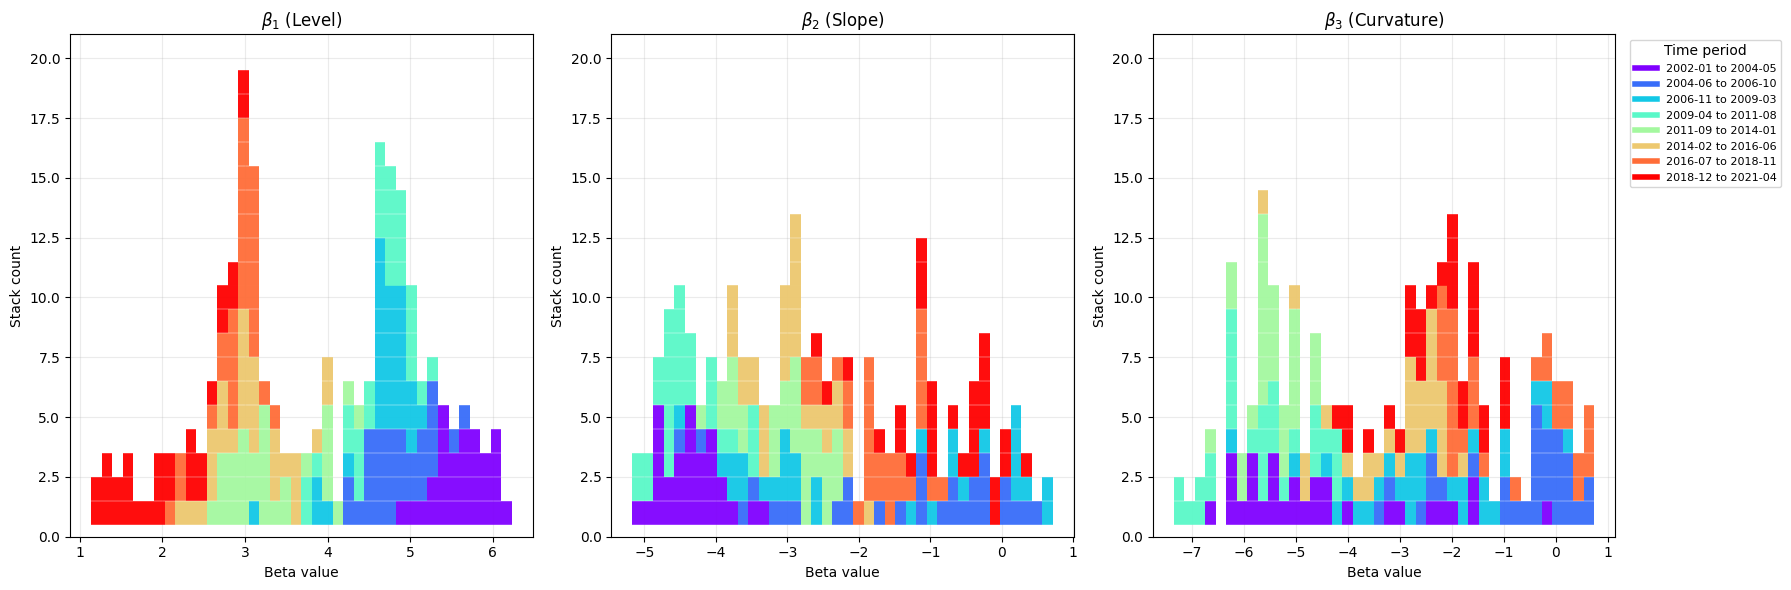

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609

HIST_MATS_YR = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO = HIST_MATS_YR * 12

def ns_loadings(tau, lam):
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    X = ns_loadings(tau, lam)
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas

# ── Load data ───────────────────────────────────────────────────────────────
historical_data = historical_data

hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]
hist_monthly = hist.resample('ME').last().dropna()

# ── Fit NS ──────────────────────────────────────────────────────────────────
hist_betas = np.array([
    fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    for _, row in hist_monthly.iterrows()
])

dates = hist_monthly.index
n_obs = len(dates)

beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]

# ── Time coloring ───────────────────────────────────────────────────────────
n_periods = 8
period_edges = np.linspace(0, n_obs, n_periods + 1, dtype=int)
period_ids = np.zeros(n_obs, dtype=int)

for p in range(n_periods):
    period_ids[period_edges[p]:period_edges[p+1]] = p

colors = plt.cm.rainbow(np.linspace(0, 1, n_periods))

period_labels = []
for p in range(n_periods):
    start = dates[period_edges[p]]
    end = dates[period_edges[p+1]-1]
    period_labels.append(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")

# ── Compute GLOBAL Y max only ────────────────────────────────────────────────
n_bins = 40
global_max_stack = 0

for i in range(3):
    vals = hist_betas[:, i]
    
    # IMPORTANT: each plot keeps its own x-range → use local binning
    vmin, vmax = vals.min(), vals.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    
    bin_idx = np.digitize(vals, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        count = np.sum(bin_idx == b)
        global_max_stack = max(global_max_stack, count)

# ── Plot function ───────────────────────────────────────────────────────────
def stacked_bin_bars(ax, values, period_ids, colors, ymax):
    vmin, vmax = values.min(), values.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]

    bin_idx = np.digitize(values, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        idx = np.where(bin_idx == b)[0]
        if len(idx) == 0:
            continue

        idx = idx[np.argsort(idx)]

        for stack_level, obs_idx in enumerate(idx, start=1):
            x_center = bin_centers[b]

            ax.hlines(
                y=stack_level,
                xmin=x_center - 0.5 * bin_width,
                xmax=x_center + 0.5 * bin_width,
                color=colors[period_ids[obs_idx]],
                linewidth=17,
                alpha=0.95
            )

    ax.set_ylim(0, ymax)
    ax.set_ylabel("Stack count")
    ax.grid(True, alpha=0.25)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    stacked_bin_bars(
        ax=ax,
        values=hist_betas[:, i],
        period_ids=period_ids,
        colors=colors,
        ymax=global_max_stack + 2
    )
    ax.set_title(beta_labels[i])
    ax.set_xlabel("Beta value")

# Legend
handles = [plt.Line2D([0], [0], color=colors[p], lw=4) for p in range(n_periods)]
axes[2].legend(handles, period_labels, title="Time period",
               loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=8)

plt.tight_layout()
plt.show()

### historical data volatility

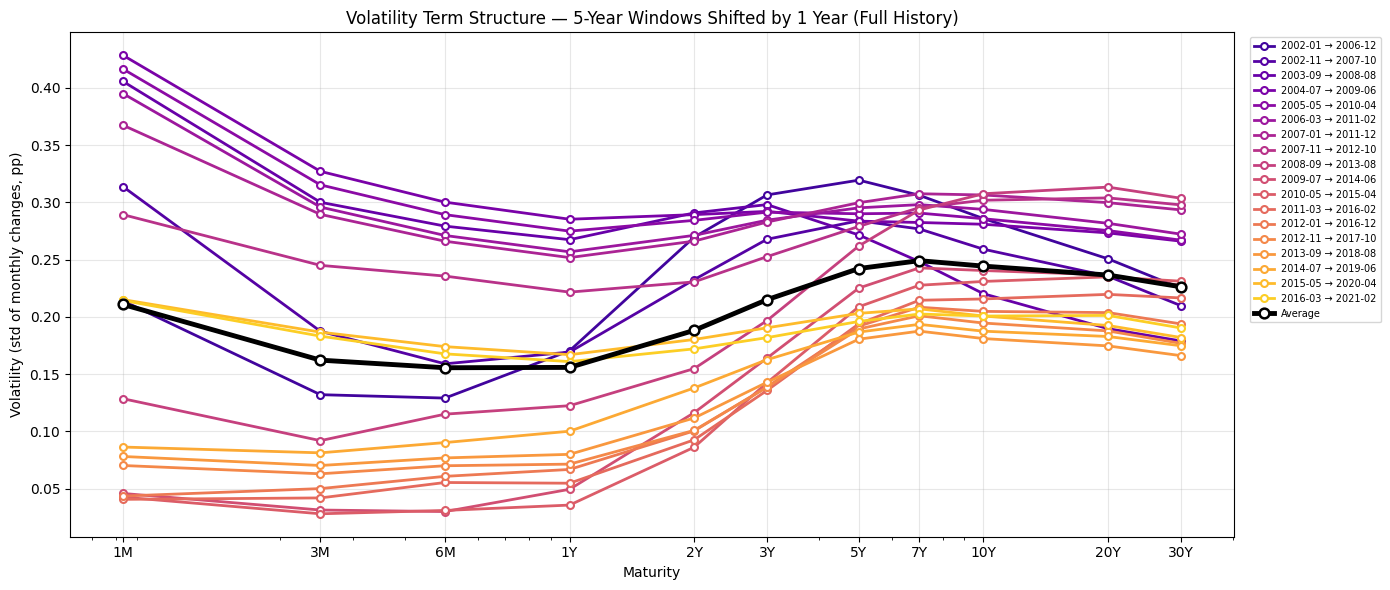

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(historical_data)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE").sort_index()

yield_cols     = [c for c in df.columns if c.startswith("Yield_")]
maturities     = [c.replace("Yield_", "") for c in yield_cols]
maturity_years = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]

yields_monthly = df[yield_cols].resample("ME").last()

WINDOW = 60   # 5 years
STEP   = 10   # shift by 1 year

windows = []
for start in range(0, len(yields_monthly) - WINDOW + 1, STEP):
    window = yields_monthly.iloc[start : start + WINDOW]
    label  = f"{window.index[0].strftime('%Y-%m')} → {window.index[-1].strftime('%Y-%m')}"
    windows.append((label, window))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(windows)))

fig, ax = plt.subplots(figsize=(14, 6))
all_vol_values = []

for (label, window), color in zip(windows, colors):
    vol        = window.diff().dropna().std()
    vol_values = [vol[col] for col in yield_cols]
    all_vol_values.append(vol_values)
    ax.plot(maturity_years, vol_values, color=color, linewidth=2,
            marker="o", markersize=5, markerfacecolor="white",
            markeredgewidth=1.5, label=label)

# Black average curve on top
all_vol_values = np.array(all_vol_values)
avg_vol_values = all_vol_values.mean(axis=0)
ax.plot(maturity_years, avg_vol_values,
        color="black", linewidth=3.5,
        marker="o", markersize=7,
        markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.8,
        label="Average")

ax.set_xscale("log")
ax.set_xticks(maturity_years)
ax.set_xticklabels(maturities)
ax.set_xlabel("Maturity")
ax.set_ylabel("Volatility (std of monthly changes, pp)")
ax.set_title("Volatility Term Structure — 5-Year Windows Shifted by 1 Year (Full History)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("volatility_all_windows.png", dpi=150, bbox_inches="tight")
plt.show()

## Preprossessing historical data

In [246]:
# ─────────────────────────────────────────────
# Historical-data preparation
# ─────────────────────────────────────────────
# The historical CSV contains daily observations of the yield curve plus three
# macro columns (FedFunds, CPI_Level, Real_GDP). For the evaluation we need:
#   1. daily → monthly data (end-of-month value)
#   2. drop the three macro columns so only the yield curve remains
#   3. build rolling windows of 60 timesteps, shifting by 1 month each time
#      (comparable to the 60-month generated scenarios)
#
# `prepare_historical_data` is the single entry point used everywhere in this
# notebook whenever we need the monthly historical data or rolling windows.

HIST_YIELD_COLS = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y",
]
MACRO_COLS   = ["FedFunds", "CPI_Level", "Real_GDP"]
WINDOW_SIZE  = 60     # rolling window length (months) — matches scenario horizon
WINDOW_STEP  = 1      # shift by 1 month (rolling, not tumbling)


def prepare_historical_data(path=historical_data,
                            window=WINDOW_SIZE,
                            step=WINDOW_STEP):
    """
    Transform the raw historical CSV into the objects used by every
    evaluation section.

    Steps
    -----
    1. Parse DATE, sort, set as index.
    2. Resample daily → monthly (end-of-month) keeping the last observation
       of every month.
    3. Drop the three macro columns (FedFunds, CPI_Level, Real_GDP); only
       the 11 yield-curve columns remain.
    4. Build rolling windows of `window` months shifted by `step` months.

    Returns
    -------
    hist_monthly : pd.DataFrame
        (n_months, 11) — monthly yield curve, indexed by month-end DATE.
    hist_windows : np.ndarray
        (n_windows, window, 11) — rolling windows of the monthly data.
    """
    # 1. load
    df = pd.read_csv(path, parse_dates=["DATE"])
    df = df.set_index("DATE").sort_index()

    # 2. daily → monthly (end-of-month: last observation per month)
    monthly = df.resample("ME").last()

    # 3. drop the three macro columns — keep only the yield curve
    monthly = monthly.drop(columns=MACRO_COLS, errors="ignore")
    monthly = monthly[HIST_YIELD_COLS].dropna()

    # 4. rolling windows of `window` months, shift = `step`
    arr = monthly.values                 # (n_months, 11)
    n   = len(arr)
    if n < window:
        raise ValueError(f"Only {n} monthly observations; need at least {window}.")
    windows = np.stack([arr[s:s + window]
                        for s in range(0, n - window + 1, step)])
    return monthly, windows


# Run once and expose the results as module-level globals so every downstream
# cell can reuse them without re-loading or re-resampling the raw csv.
hist_monthly, hist_windows = prepare_historical_data()

print(f"Historical monthly observations : {hist_monthly.shape[0]}  "
      f"({hist_monthly.index[0].strftime('%Y-%m')} → "
      f"{hist_monthly.index[-1].strftime('%Y-%m')})")
print(f"Columns retained                : {list(hist_monthly.columns)}")
print(f"Rolling windows (60m, step 1)   : {hist_windows.shape}  "
      f"(n_windows, window, n_maturities)")


Historical monthly observations : 232  (2002-01 → 2021-04)
Columns retained                : ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y', 'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']
Rolling windows (60m, step 1)   : (173, 60, 11)  (n_windows, window, n_maturities)


# Comparing models

## 4.5.2 Volatility Structure

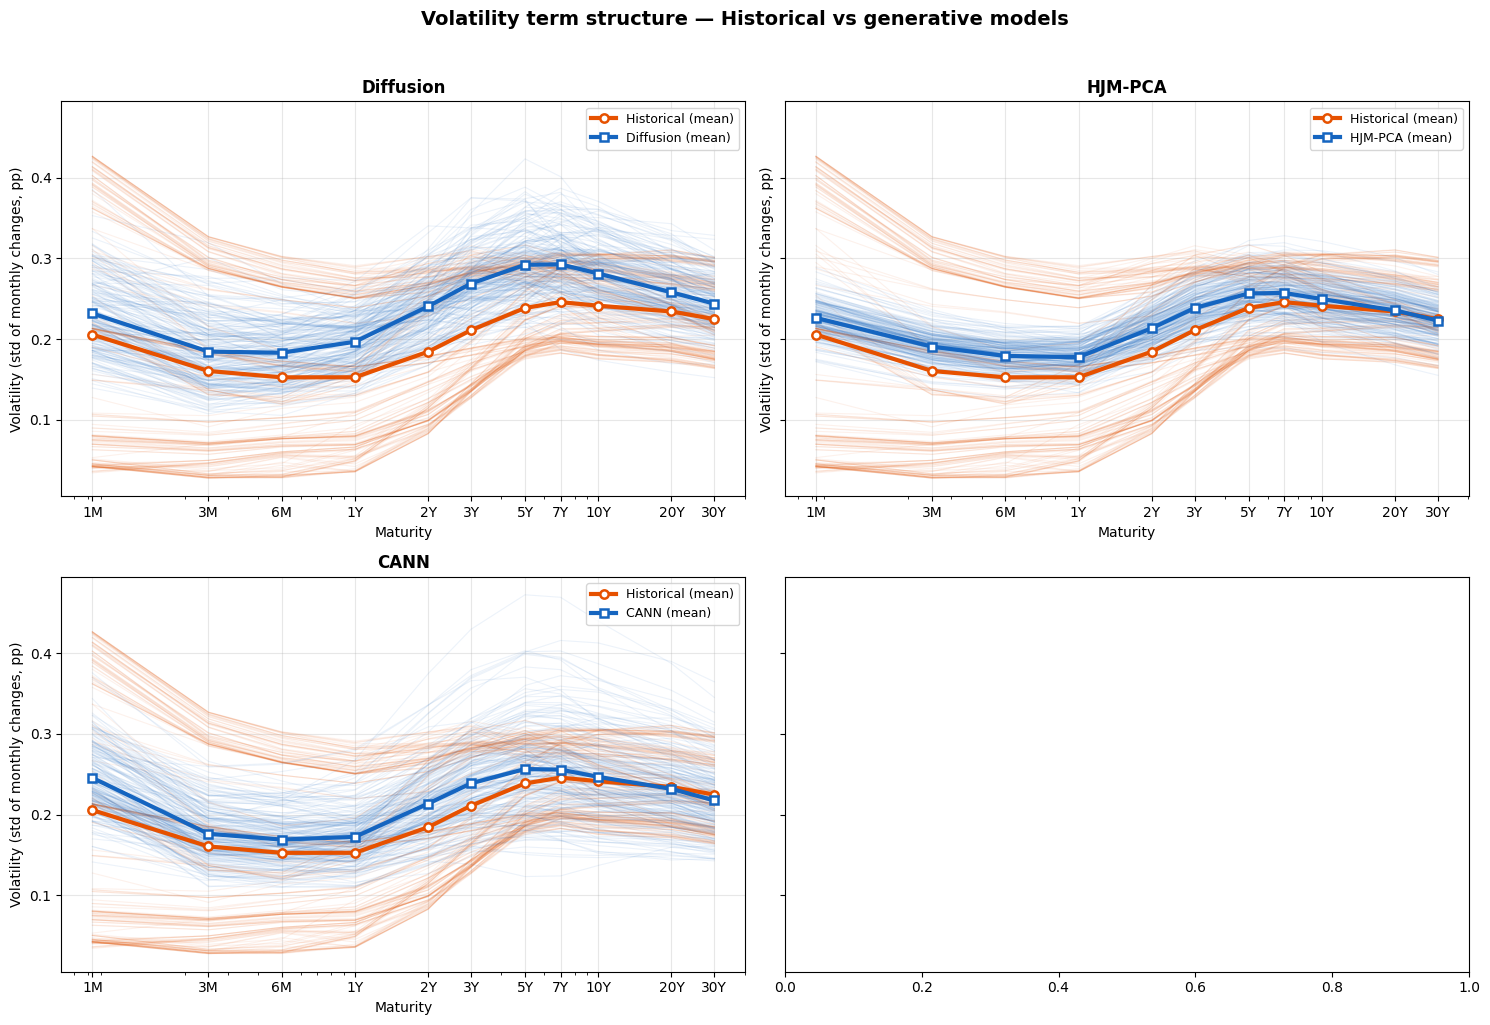

In [247]:
# ─────────────────────────────────────────────
# Volatility term structure — Historical vs every generative model
# ─────────────────────────────────────────────
# For every 60-month rolling window (historical) and every scenario (simulated)
# we compute the volatility curve: std of monthly changes per maturity.
# This is the same object, just coming from a different source — so the
# historical hist_windows and the simulated scenarios are directly comparable.
import matplotlib.pyplot as plt

SIM_YIELD_COLS = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                  "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MATURITY_YEARS  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])


def vol_curve(arr):
    """
    Volatility curve per maturity: std of monthly changes.
    Accepts (T, M) for a single path, or (N, T, M) for a batch of N paths.
    Returns (M,) or (N, M).
    """
    return np.diff(arr, axis=-2).std(axis=-2)


def scenario_tensor(path):
    """
    Load a scenario csv and reshape into (n_scenarios, n_months, n_maturities).
    """
    df = load_scenarios(path)
    sids = sorted(df["Scenario_ID"].unique())
    return np.stack([df[df["Scenario_ID"] == s]
                       .sort_values("Month")[SIM_YIELD_COLS]
                       .values
                     for s in sids])


# Historical volatility curves — one per 60-month rolling window
hist_vol_curves = vol_curve(hist_windows)           # (n_windows, 11)
hist_vol_mean   = hist_vol_curves.mean(axis=0)      # (11,)

# Simulated volatility curves — one per scenario, per model
sim_vol_curves = {name: vol_curve(scenario_tensor(path))
                  for name, path in MODELS.items()}


# ─────────────────────────────────────────────
# Plot: 2×2 grid, one panel per model
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Volatility term structure — Historical vs generative models",
             fontsize=14, fontweight="bold", y=1.02)

HIST_C   = "#E65100"    # orange
SIM_C    = "#1565C0"    # blue

for ax, (name, curves) in zip(axes.flat, sim_vol_curves.items()):
    # thin lines = individual paths
    for v in hist_vol_curves:
        ax.plot(MATURITY_YEARS, v, color=HIST_C, alpha=0.08, lw=0.8)
    for v in curves:
        ax.plot(MATURITY_YEARS, v, color=SIM_C,  alpha=0.08, lw=0.8)

    # mean curves
    ax.plot(MATURITY_YEARS, hist_vol_mean, color=HIST_C, lw=3,
            marker="o", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label="Historical (mean)")
    ax.plot(MATURITY_YEARS, curves.mean(axis=0), color=SIM_C, lw=3,
            marker="s", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label=f"{name} (mean)")

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Volatility (std of monthly changes, pp)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


### Mean curve error
For each model we compute the per-scenario squared deviation between the simulated and mean historical volatility curve, then aggregate across the 200 scenarios.

In [248]:
# ─────────────────────────────────────────────
# Mean curve error
# ─────────────────────────────────────────────
# For each scenario i and model m the deviation between the simulated and
# mean-historical volatility curve is
#         E_i^curve = (1/M) * Σ_m (σ_i,m - σ_m^hist)²
# These per-scenario errors are then aggregated to a mean and a median across
# the 200 scenarios of each model.

curve_error_rows = []
for name, curves in sim_vol_curves.items():
    per_scen = ((curves - hist_vol_mean[None, :]) ** 2).mean(axis=1)
    curve_error_rows.append({
        "Model":            name,
        "Mean E_curve":     per_scen.mean(),
        "Median E_curve":   np.median(per_scen),
        "Std E_curve":      per_scen.std(),
        "Min E_curve":      per_scen.min(),
        "Max E_curve":      per_scen.max(),
    })

curve_error_df = pd.DataFrame(curve_error_rows).set_index("Model")

print("Mean curve error — lower is better")
print("=" * 70)
print(curve_error_df.round(5).to_string())


Mean curve error — lower is better
           Mean E_curve  Median E_curve  Std E_curve  Min E_curve  Max E_curve
Model                                                                         
Diffusion         0.003           0.003        0.002        0.000        0.010
HJM-PCA           0.001           0.001        0.001        0.000        0.004
CANN              0.002           0.001        0.003        0.000        0.026


### Volatility distribution analysis (short vs long maturities)
Short-term maturity is the 1-month rate; long-term is the average of the 10Y, 20Y and 30Y rates. Rolling windows of 1-year and 5-year are used to build the distribution of volatility estimates for each model and the historical data. The distributions are compared via mean, spread (P95 - P5), Wasserstein distance, extreme-volatility-frequency (EVF) error, skewness and kurtosis.

In [249]:
# ─────────────────────────────────────────────
# Volatility distribution — short (1M) vs long (avg 10Y/20Y/30Y) maturities
# ─────────────────────────────────────────────
# Using 1-year and 5-year rolling windows on monthly yield changes we obtain,
# for each model and for the historical data, a distribution of volatility
# estimates. The distributions are then compared along:
#   • mean and spread (P95 - P5)
#   • Wasserstein distance (overall shape match)
#   • EVF Error   = |p_sim - p_hist| where p is the proportion of obs. above
#                  the historical 95th percentile (extreme volatility freq.)
#   • skewness and kurtosis (descriptive, tail shape)
from scipy.stats import wasserstein_distance, skew, kurtosis

SHORT_HIST = "Yield_1M"
LONG_HIST  = ["Yield_10Y", "Yield_20Y", "Yield_30Y"]
SHORT_SIM  = "Y_1M"
LONG_SIM   = ["Y_10Y", "Y_20Y", "Y_30Y"]


def rolling_vol(series, window):
    """Rolling-window std of first differences; falls back to full-series std
    when the series is too short for the requested window."""
    diffs = series.diff().dropna()
    if window <= len(diffs):
        return diffs.rolling(window).std().dropna().values
    return np.array([diffs.std()])


def hist_vol_dist(cols, window):
    series = hist_monthly[cols].mean(axis=1) if isinstance(cols, list) else hist_monthly[cols]
    return rolling_vol(series, window)


def sim_vol_dist(path, cols, window):
    df = load_scenarios(path)
    out = []
    for _, g in df.groupby("Scenario_ID"):
        g = g.sort_values("Month")
        series = g[cols].mean(axis=1) if isinstance(cols, list) else g[cols]
        out.append(rolling_vol(series, window))
    return np.concatenate(out)


# ─────────────────────────────────────────────
# Compute distributions for each (window, maturity-segment, model)
# ─────────────────────────────────────────────
dist_rows = []
for window_label, window in [("1Y", 12), ("5Y", 60)]:
    for seg_label, hcols, scols in [
        ("Short (1M)",                SHORT_HIST, SHORT_SIM),
        ("Long (avg 10Y/20Y/30Y)",    LONG_HIST,  LONG_SIM),
    ]:
        h = hist_vol_dist(hcols, window)
        h_p95   = np.percentile(h, 95)
        h_mean  = h.mean()
        h_spread = np.percentile(h, 95) - np.percentile(h, 5)
        p_hist  = (h > h_p95).mean()

        # historical reference row
        dist_rows.append({
            "Window":     window_label,
            "Maturity":   seg_label,
            "Model":      "Historical",
            "Mean":       h_mean,
            "Spread":     h_spread,
            "Wasserstein": 0.0,
            "EVF Error":  0.0,
            "Skew":       skew(h),
            "Kurt":       kurtosis(h),
        })

        for name, path in MODELS.items():
            s = sim_vol_dist(path, scols, window)
            p_sim = (s > h_p95).mean()
            dist_rows.append({
                "Window":     window_label,
                "Maturity":   seg_label,
                "Model":      name,
                "Mean":       s.mean(),
                "Spread":     np.percentile(s, 95) - np.percentile(s, 5),
                "Wasserstein": wasserstein_distance(h, s),
                "EVF Error":  abs(p_sim - p_hist),
                "Skew":       skew(s),
                "Kurt":       kurtosis(s),
            })

dist_df = pd.DataFrame(dist_rows)

# Pretty print grouped by window + maturity segment
print("Volatility distribution analysis — short vs long maturities")
print("=" * 90)
for (window, seg), sub in dist_df.groupby(["Window", "Maturity"], sort=False):
    print(f"\n── {window} rolling window · {seg} ──")
    print(sub.drop(columns=["Window", "Maturity"])
            .set_index("Model")
            .round(4)
            .to_string())


Volatility distribution analysis — short vs long maturities

── 1Y rolling window · Short (1M) ──
            Mean  Spread  Wasserstein  EVF Error  Skew   Kurt
Model                                                        
Historical 0.167   0.558        0.000      0.000 1.504  1.312
Diffusion  0.216   0.321        0.089      0.044 1.438  2.330
HJM-PCA    0.224   0.155        0.131      0.050 0.111 -0.035
CANN       0.238   0.274        0.113      0.050 1.008  1.317

── 1Y rolling window · Long (avg 10Y/20Y/30Y) ──
            Mean  Spread  Wasserstein  EVF Error  Skew  Kurt
Model                                                       
Historical 0.227   0.235        0.000      0.000 1.585 2.717
Diffusion  0.251   0.275        0.027      0.037 0.778 0.684
HJM-PCA    0.232   0.164        0.024      0.044 0.284 0.176
CANN       0.218   0.288        0.022      0.018 1.005 1.153

── 5Y rolling window · Short (1M) ──
            Mean  Spread  Wasserstein  EVF Error   Skew   Kurt
Model        

## 4.5.1 Temporal Dynamics (ACF)

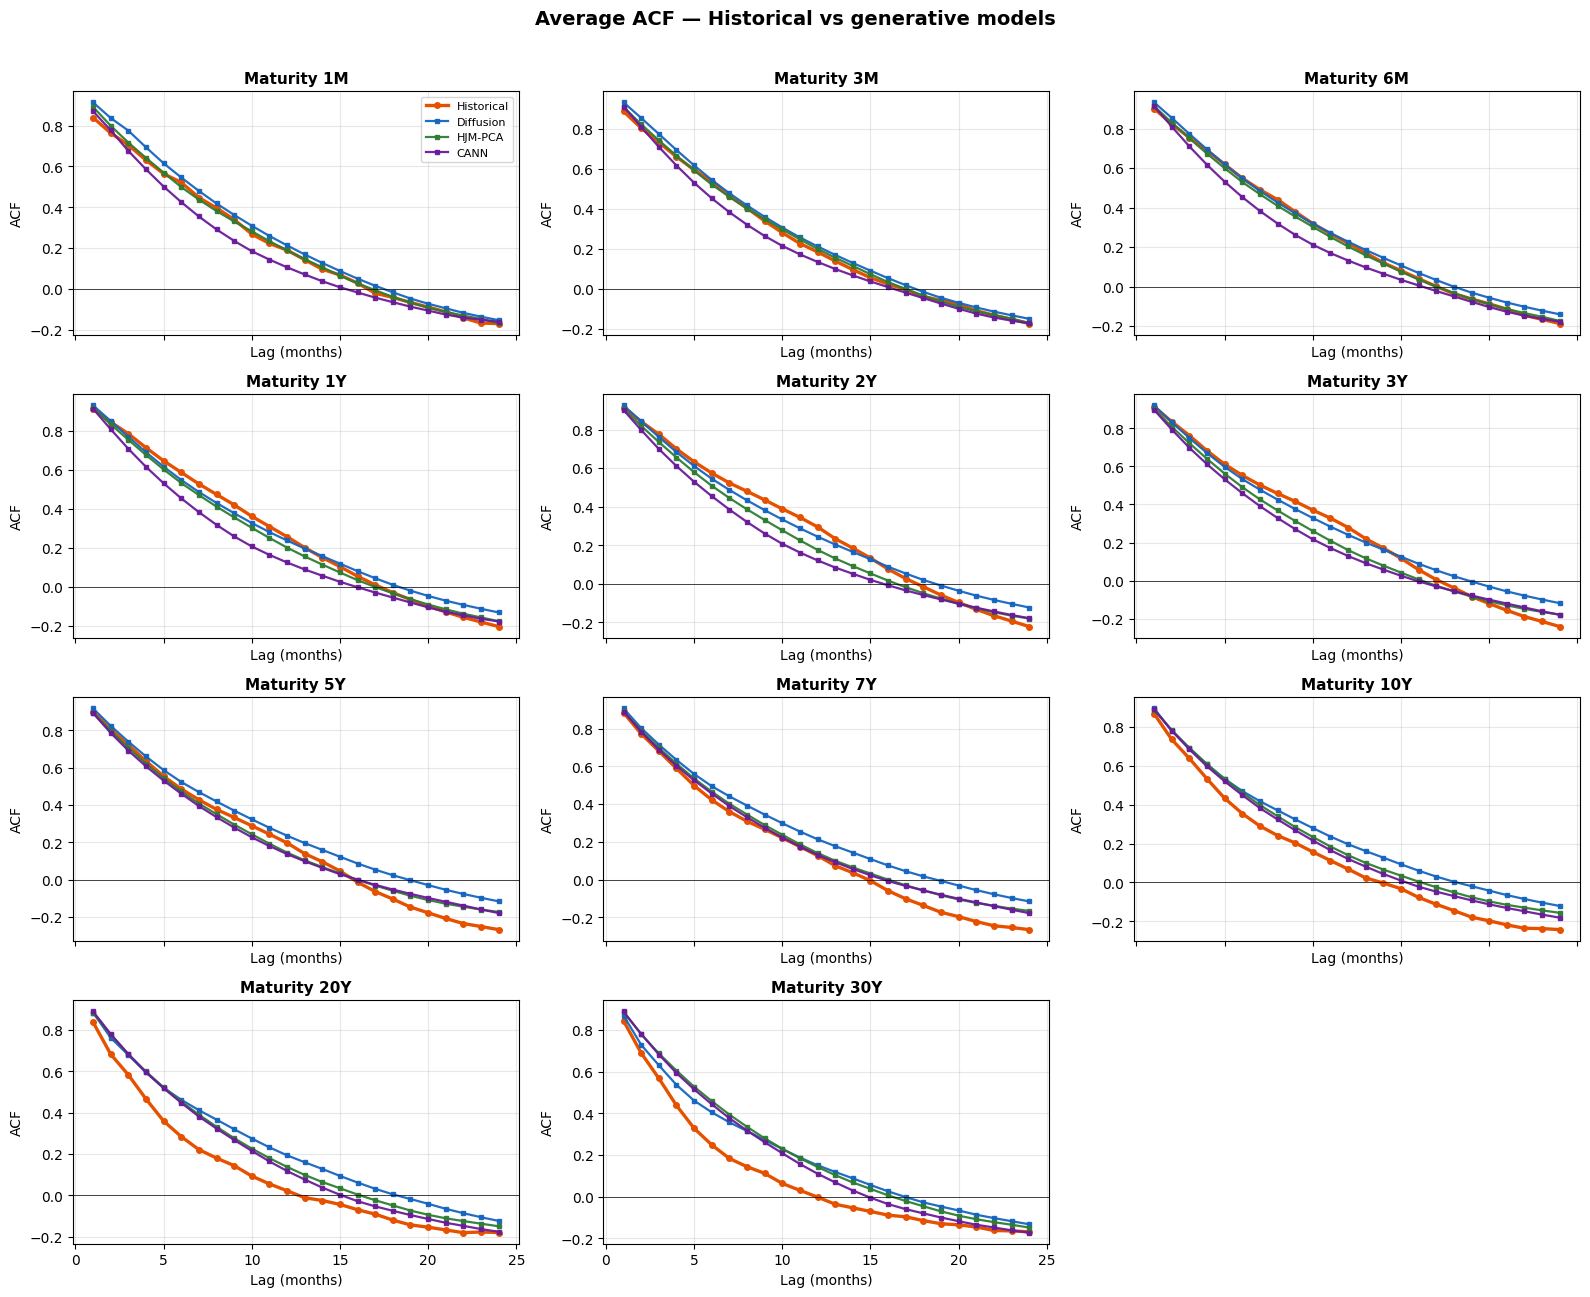

In [250]:
# ─────────────────────────────────────────────
# ACF — Historical vs every generative model
# ─────────────────────────────────────────────
# For every 60-month rolling window (historical) and every scenario (simulated)
# we compute the autocorrelation function per maturity up to K = 24 lags
# (a 2-year horizon, as in the evaluation). The mean historical ACF is the
# average across all hist_windows; the mean simulated ACF is the average
# across the 200 scenarios of each model.
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

N_LAGS = 24                 # K in the evaluation (2-year horizon)
LAGS   = np.arange(1, N_LAGS + 1)


def acf_batch(paths, nlags=N_LAGS):
    """
    paths : (N, T, M)          — N paths, T timesteps, M maturities
    Returns (N, M, nlags) — ACF at lags 1..nlags, excluding lag 0.
    """
    N, T, M = paths.shape
    out = np.zeros((N, M, nlags))
    for n in range(N):
        for m in range(M):
            s = paths[n, :, m]
            if np.std(s) < 1e-10:
                continue
            out[n, m] = acf(s, nlags=nlags, fft=True)[1:]
    return out


# Historical ACF — averaged across every 60-month rolling window
hist_acf       = acf_batch(hist_windows)          # (n_windows, 11, K)
hist_acf_mean  = hist_acf.mean(axis=0)            # (11, K)

# Simulated ACF — one per scenario, averaged, per model
sim_acf       = {name: acf_batch(scenario_tensor(path))
                 for name, path in MODELS.items()}
sim_acf_mean  = {name: a.mean(axis=0) for name, a in sim_acf.items()}


# ─────────────────────────────────────────────
# Plot: 4×3 grid, one panel per maturity, all models on top of historical
# ─────────────────────────────────────────────
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}
HIST_COLOR = "#E65100"

n_mat = len(MATURITY_LABELS)
ncols = 3
nrows = int(np.ceil(n_mat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2), sharex=True)
fig.suptitle("Average ACF — Historical vs generative models",
             fontsize=14, fontweight="bold", y=1.01)

for idx, label in enumerate(MATURITY_LABELS):
    ax = axes.flat[idx]
    ax.plot(LAGS, hist_acf_mean[idx], color=HIST_COLOR, lw=2.4,
            marker="o", markersize=4, label="Historical")
    for name, mat_acf in sim_acf_mean.items():
        ax.plot(LAGS, mat_acf[idx], color=MODEL_COLORS[name], lw=1.6,
                alpha=0.95, marker="s", markersize=3, label=name)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Maturity {label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("ACF")
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8, loc="upper right")

for ax in axes.flat[n_mat:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### Per-maturity deviation score
For each maturity and model we compute the mean squared deviation between the simulated and historical average ACF (K = 24 lags), then average across the 200 scenarios. The bottom *Average* row collapses this further to a single number per model.

In [251]:
# ─────────────────────────────────────────────
# Per-maturity deviation score  S̄_m
# ─────────────────────────────────────────────
# For each scenario i and maturity m:
#         S_{i,m} = (1/K) Σ_k (ρ̂_{i,k,m} - ρ̄_k,m^{hist})²
# then averaged across the 200 scenarios of each model:
#         S̄_m     = (1/n) Σ_i S_{i,m}
# Lower values = the model reproduces the persistence structure at that
# maturity more faithfully.

per_mat_rows = {}
for name, a in sim_acf.items():
    # squared deviation per scenario, per maturity, averaged over lags → S_{i,m}
    S_im        = ((a - hist_acf_mean[None, :, :]) ** 2).mean(axis=2)   # (n_scen, 11)
    per_mat_rows[name] = S_im.mean(axis=0)                              # (11,)

acf_per_mat_df = pd.DataFrame(per_mat_rows, index=MATURITY_LABELS)
acf_per_mat_df.index.name = "Maturity"

# append column-average row
acf_per_mat_df.loc["Average"] = acf_per_mat_df.mean()

print("Per-maturity ACF deviation score  S̄_m  — lower is better")
print("=" * 70)
print(acf_per_mat_df.round(5).to_string())


Per-maturity ACF deviation score  S̄_m  — lower is better
          Diffusion  HJM-PCA  CANN
Maturity                          
1M            0.028    0.032 0.040
3M            0.027    0.031 0.037
6M            0.026    0.031 0.038
1Y            0.026    0.031 0.042
2Y            0.025    0.034 0.046
3Y            0.027    0.035 0.042
5Y            0.032    0.034 0.037
7Y            0.038    0.036 0.038
10Y           0.042    0.040 0.040
20Y           0.044    0.043 0.044
30Y           0.042    0.049 0.048
Average       0.033    0.036 0.041


### Global deviation score
The global score averages the per-maturity score over all 11 maturities within each scenario, then aggregates over the 200 scenarios. A single number summarises how well each model reproduces the persistence structure across the yield curve.

In [252]:
# ─────────────────────────────────────────────
# Global deviation score  S̄^{global}
# ─────────────────────────────────────────────
# Per-scenario global score averages S_{i,m} over all maturities:
#         S_i^{global} = (1/M) Σ_m S_{i,m}
# and the mean global score averages over scenarios:
#         S̄^{global}   = (1/n) Σ_i S_i^{global}

global_rows = []
for name, a in sim_acf.items():
    S_im         = ((a - hist_acf_mean[None, :, :]) ** 2).mean(axis=2)  # (n_scen, 11)
    S_global_i   = S_im.mean(axis=1)                                    # (n_scen,)
    global_rows.append({
        "Model":             name,
        "Mean S^global":     S_global_i.mean(),
        "Median S^global":   np.median(S_global_i),
        "Std S^global":      S_global_i.std(),
        "Min S^global":      S_global_i.min(),
        "Max S^global":      S_global_i.max(),
    })

acf_global_df = pd.DataFrame(global_rows).set_index("Model")

print("Global ACF deviation score  S̄^global  — lower is better")
print("=" * 70)
print(acf_global_df.round(5).to_string())


Global ACF deviation score  S̄^global  — lower is better
           Mean S^global  Median S^global  Std S^global  Min S^global  Max S^global
Model                                                                              
Diffusion          0.033            0.030         0.018         0.007         0.093
HJM-PCA            0.036            0.033         0.021         0.007         0.120
CANN               0.041            0.037         0.021         0.006         0.116


## 4.5.4 Yield Curve Shape — Nelson–Siegel

Fit the Nelson–Siegel decomposition (fixed λ = 0.0609, Diebold-Li convention) to every yield curve in the historical dataset and in all four generative models. Compare the resulting β-factor distributions visually and via Wasserstein distance.

Historical betas : (232, 3)  (2002-01 → 2021-04)
  Diffusion   : 12,000 yield-curve obs   β1 μ=3.844 β2 μ=-0.984 β3 μ=-5.866
  HJM-PCA     : 12,000 yield-curve obs   β1 μ=5.143 β2 μ=-1.365 β3 μ=-2.306
  CANN        : 12,000 yield-curve obs   β1 μ=4.378 β2 μ=-0.303 β3 μ=-2.593


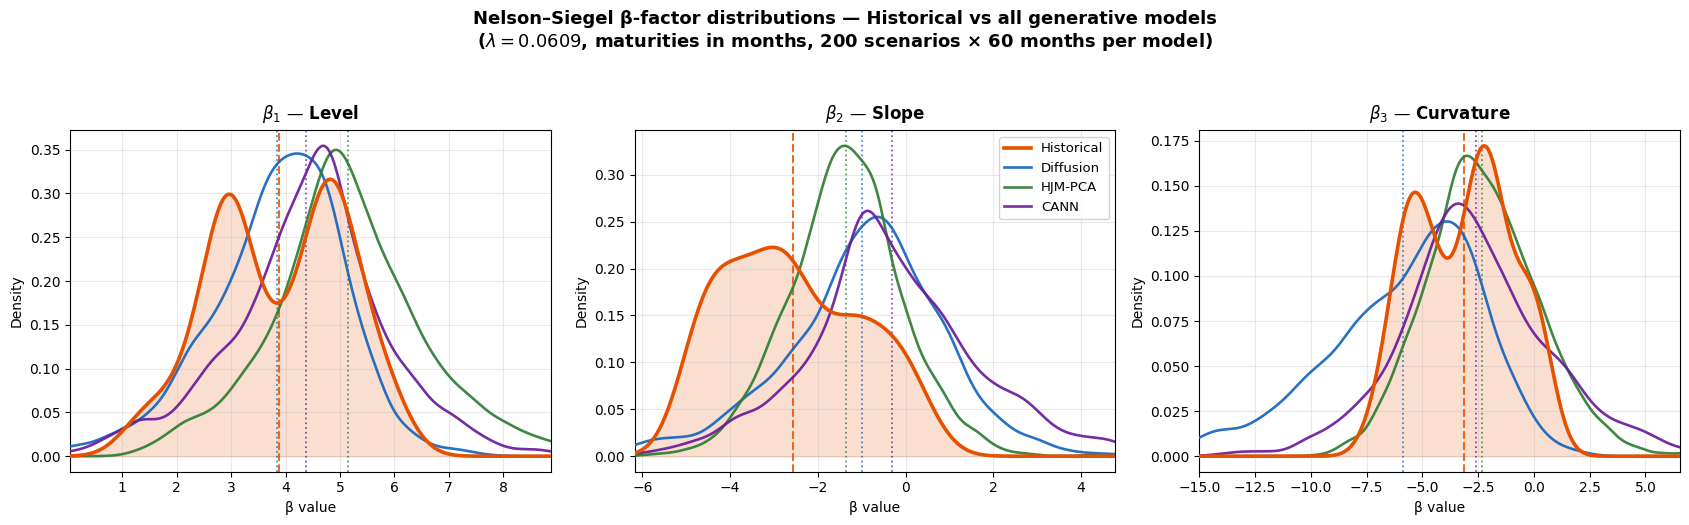


Dashed vertical lines = distribution means.


In [253]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.5.4  Yield Curve Shape — Nelson–Siegel  (all models side-by-side)
# ─────────────────────────────────────────────────────────────────────────────
# Strategy:
#   • For the historical dataset (hist_monthly, already loaded in cell 11)
#     fit NS to each monthly observation → (n_months, 3) betas.
#   • For each generative model load all rows from load_scenarios() —
#     that is 200 scenarios × 60 months = 12 000 yield curves per model —
#     and fit NS to every row → (12000, 3) betas.
#   • Plot a 1×3 KDE grid: one panel per β-factor, all models + historical
#     overlaid so the reader can directly compare distributions.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

# ── Nelson–Siegel helpers ─────────────────────────────────────────────────────
NS_LAMBDA     = 0.0609                                    # fixed (Diebold-Li)
MATS_MONTHS   = np.array([1/12, 3/12, 6/12, 1, 2, 3,
                           5, 7, 10, 20, 30]) * 12        # maturities in months
SIM_YLD_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                 "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
HIST_YLD_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                 "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y",
                 "Yield_20Y","Yield_30Y"]

def _ns_matrix(mats, lam):
    lt = lam * mats
    return np.column_stack([np.ones_like(lt),
                            (1 - np.exp(-lt)) / lt,
                            (1 - np.exp(-lt)) / lt - np.exp(-lt)])

_NS_X = _ns_matrix(MATS_MONTHS, NS_LAMBDA)   # (11, 3)  — reused for all fits

def fit_betas(yield_matrix):
    """
    OLS Nelson–Siegel fit for every row of yield_matrix.
    yield_matrix : (n_curves, 11)
    Returns      : (n_curves, 3)  — [β1 Level, β2 Slope, β3 Curvature]
    """
    betas, _, _, _ = np.linalg.lstsq(_NS_X, yield_matrix.T, rcond=None)
    return betas.T

# ── Historical betas ──────────────────────────────────────────────────────────
hist_betas_shape = fit_betas(hist_monthly[HIST_YLD_COLS].values)
print(f"Historical betas : {hist_betas_shape.shape}  "
      f"({hist_monthly.index[0].strftime('%Y-%m')} → "
      f"{hist_monthly.index[-1].strftime('%Y-%m')})")

# ── Simulated betas for every model ──────────────────────────────────────────
sim_betas_shape = {}
for name, path in MODELS.items():
    df = load_scenarios(path)                         # 200 scenarios × 60 months
    yields = df[SIM_YLD_COLS].values                 # (12 000, 11)
    sim_betas_shape[name] = fit_betas(yields)
    print(f"  {name:12s}: {sim_betas_shape[name].shape[0]:6,} yield-curve obs "
          f"  β1 μ={sim_betas_shape[name][:,0].mean():.3f} "
          f"β2 μ={sim_betas_shape[name][:,1].mean():.3f} "
          f"β3 μ={sim_betas_shape[name][:,2].mean():.3f}")

# ── Colours (consistent with rest of notebook) ───────────────────────────────
_MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}
_HIST_COLOR = "#E65100"

# ── 1×3 KDE comparison plot ───────────────────────────────────────────────────
BETA_LABELS = [
    r"$\beta_1$ — Level",
    r"$\beta_2$ — Slope",
    r"$\beta_3$ — Curvature",
]
N_GRID = 600

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Nelson–Siegel β-factor distributions — Historical vs all generative models\n"
    r"($\lambda = 0.0609$, maturities in months, 200 scenarios × 60 months per model)",
    fontsize=13, fontweight="bold", y=1.04,
)

for j, (ax, blabel) in enumerate(zip(axes, BETA_LABELS)):

    # shared x-range clipped to [0.5th, 99.5th] percentile of all data
    all_vals = np.concatenate(
        [hist_betas_shape[:, j]] +
        [b[:, j] for b in sim_betas_shape.values()]
    )
    lo = np.percentile(all_vals, 0.5)
    hi = np.percentile(all_vals, 99.5)
    x_grid = np.linspace(lo, hi, N_GRID)

    # Historical — filled shading + bold line
    h = hist_betas_shape[:, j]
    kde_h = gaussian_kde(h, bw_method="scott")
    ax.fill_between(x_grid, kde_h(x_grid), alpha=0.18, color=_HIST_COLOR)
    ax.plot(x_grid, kde_h(x_grid), lw=2.6, color=_HIST_COLOR,
            label="Historical", zorder=6)
    ax.axvline(h.mean(), color=_HIST_COLOR, ls="--", lw=1.5, alpha=0.85)

    # Each generative model — KDE line only (no fill to keep it readable)
    for name, betas in sim_betas_shape.items():
        s = betas[:, j]
        kde_s = gaussian_kde(s, bw_method="scott")
        col = _MODEL_COLORS[name]
        ax.plot(x_grid, kde_s(x_grid), lw=1.9, color=col,
                label=name, alpha=0.92, zorder=5)
        ax.axvline(s.mean(), color=col, ls=":", lw=1.3, alpha=0.75)

    ax.set_xlim(lo, hi)
    ax.set_title(blabel, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("β value", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.grid(alpha=0.28)

    # Only show legend on middle panel to keep figure clean
    if j == 1:
        ax.legend(fontsize=9.5, loc="upper right", framealpha=0.85)

plt.tight_layout()
plt.show()
print("\nDashed vertical lines = distribution means.")


In [254]:
# ─────────────────────────────────────────────────────────────────────────────
# Wasserstein Distance Summary Table — Nelson–Siegel Shape
# ─────────────────────────────────────────────────────────────────────────────
# For each model and each β-factor compute the Wasserstein-1 distance between
# the simulated distribution and the historical distribution.
# A lower value means the model better reproduces the historical yield curve
# shape distribution for that factor.
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import wasserstein_distance
import pandas as pd

factor_names = ["Level (β₁)", "Slope (β₂)", "Curvature (β₃)"]

rows = []
for name, betas in sim_betas_shape.items():
    row = {"Model": name}
    for j, fname in enumerate(factor_names):
        row[fname] = wasserstein_distance(
            hist_betas_shape[:, j], betas[:, j]
        )
    rows.append(row)

wass_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .assign(**{"Total (sum)": lambda df: df.sum(axis=1)})
    .sort_values("Total (sum)")
)

print("=" * 65)
print("   Wasserstein Distances — Nelson–Siegel β Distributions")
print("   (Historical vs simulated;  lower = better)")
print("=" * 65)
print(wass_df.round(4).to_string())
print("=" * 65)
print()
# Highlight best model per factor
for col in factor_names:
    best = wass_df[col].idxmin()
    print(f"  Best {col:20s}: {best}  (W = {wass_df.loc[best, col]:.4f})")
print(f"  Best overall (total)         : {wass_df['Total (sum)'].idxmin()}")


   Wasserstein Distances — Nelson–Siegel β Distributions
   (Historical vs simulated;  lower = better)
           Level (β₁)  Slope (β₂)  Curvature (β₃)  Total (sum)
Model                                                         
HJM-PCA         1.255       1.207           0.890        3.353
CANN            0.562       2.278           1.038        3.878
Diffusion       0.222       1.674           2.724        4.620

  Best Level (β₁)          : Diffusion  (W = 0.2223)
  Best Slope (β₂)          : HJM-PCA  (W = 1.2071)
  Best Curvature (β₃)      : HJM-PCA  (W = 0.8901)
  Best overall (total)         : HJM-PCA


## 4.5.3 Cross-Maturity Correlation

For each model, compute the average cross-maturity correlation matrix (60-month window per scenario / rolling window for historical) and plot: **Historical | Model | |Difference|** stacked one model per row. The L1 norm summarises the total absolute deviation.

Historical: 173 rolling windows of 60 months
  Diffusion   : 200 scenarios
  HJM-PCA     : 200 scenarios
  CANN        : 200 scenarios


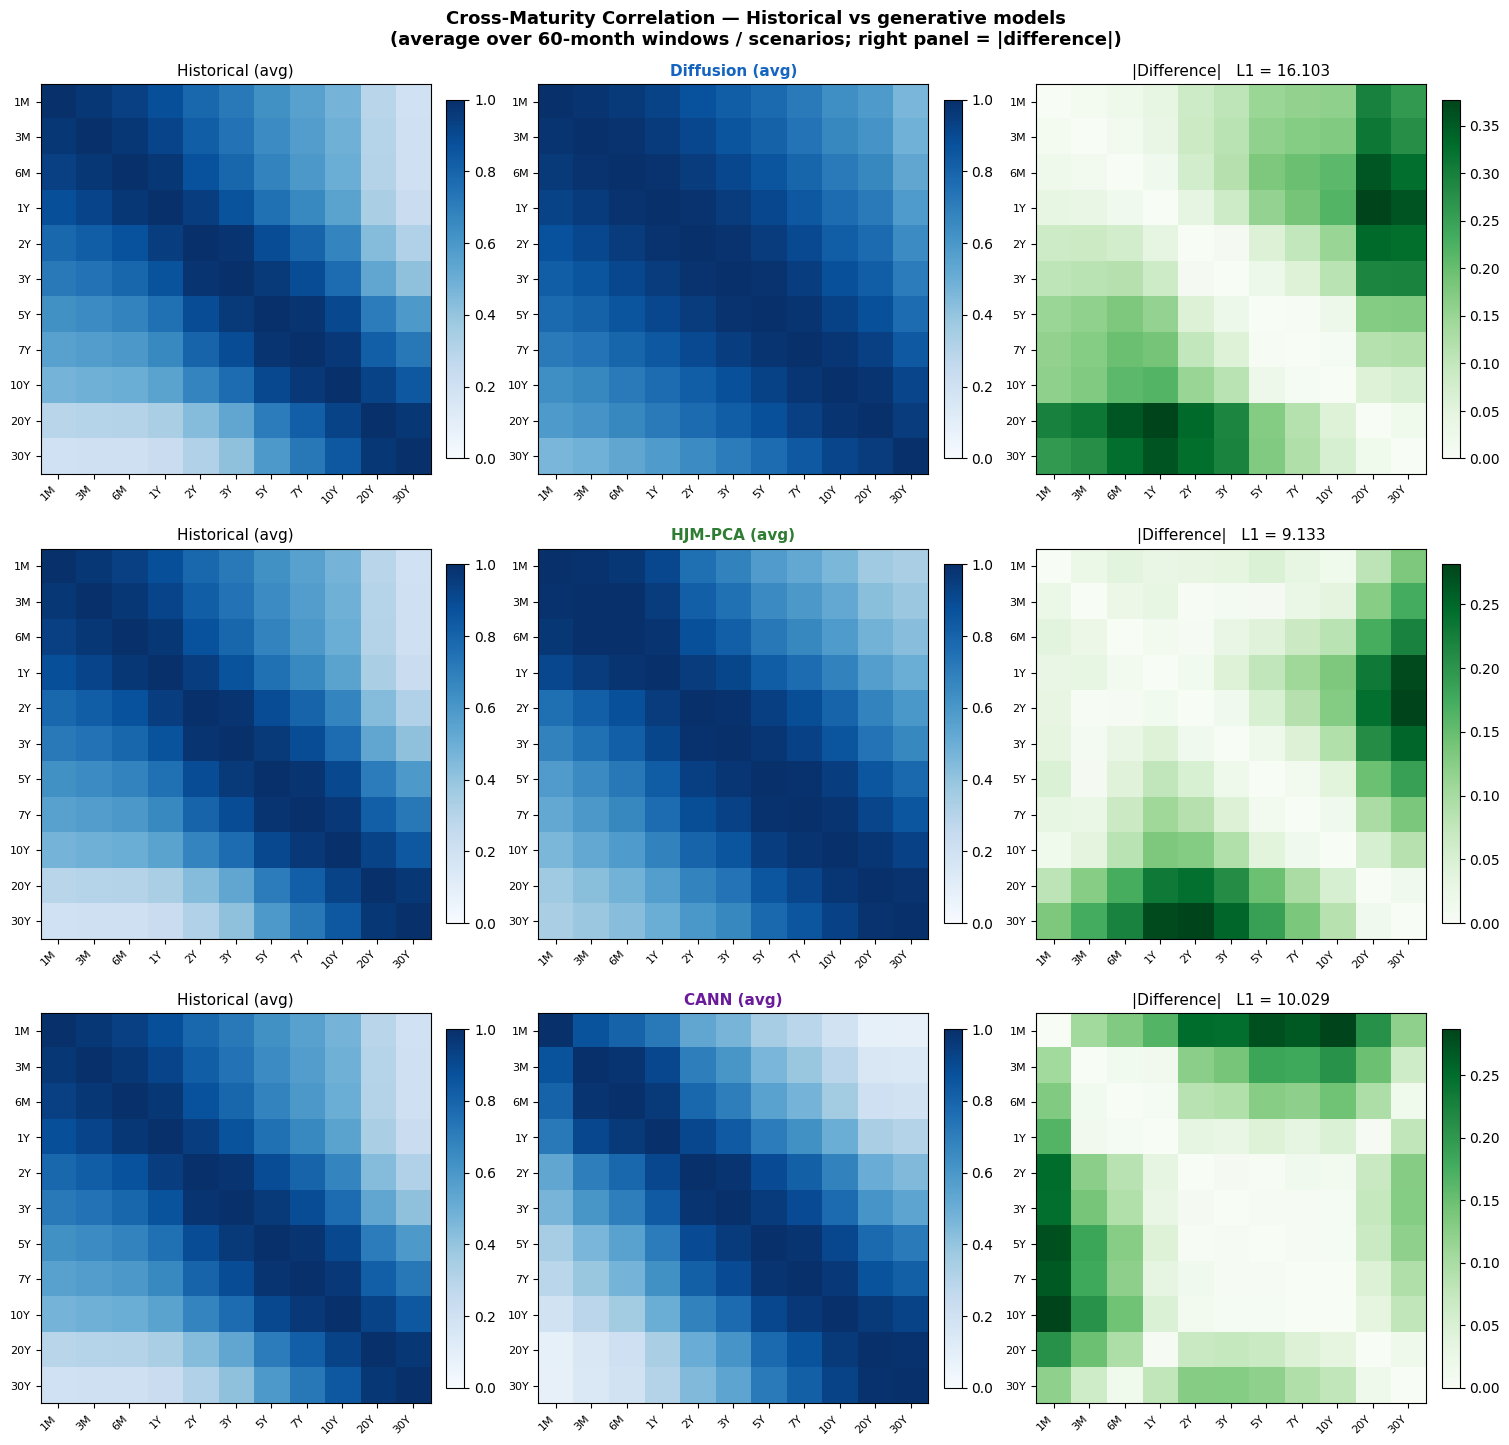


L1 norms: {'Diffusion': np.float64(16.1026), 'HJM-PCA': np.float64(9.1332), 'CANN': np.float64(10.0289)}


In [255]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.5.3  Cross-Maturity Correlation — all models, one row each
# ─────────────────────────────────────────────────────────────────────────────
# Methodology (Liao et al. 2024, Sig-Wasserstein GANs, Appendix C):
#   For each 60-month window/scenario compute the correlation matrix via
#       cov^{i,j} = (1/T) Σ X^i_t X^j_t  −  (1/T Σ X^i)(1/T Σ X^j)   [C.3]
#   Average across all windows/scenarios.
#   Metric: L1 norm = Σ_i Σ_j |τ_hist^{ij} − τ_sim^{ij}|               [C.4]
#
# Uses hist_windows and scenario_tensor() already defined above.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

YIELD_COLS_SIM  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                   "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
YIELD_COLS_HIST = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                   "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y",
                   "Yield_20Y","Yield_30Y"]
MAT_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

# ── Helper ────────────────────────────────────────────────────────────────────
def cross_corr_matrix(X):
    """X : (T, d) → (d, d) correlation matrix via Eq C.3."""
    T = X.shape[0]
    mean = X.mean(axis=0)
    cov  = (X.T @ X) / T - np.outer(mean, mean)
    std  = np.sqrt(np.diag(cov))
    denom = np.outer(std, std)
    return np.where(denom > 0, cov / denom, 0.0)

def mean_corr(windows_or_scenarios):
    """Average correlation matrix over a batch (N, T, d)."""
    return np.mean([cross_corr_matrix(w) for w in windows_or_scenarios], axis=0)

# ── Historical mean correlation (reuse hist_windows from cell 11) ─────────────
hist_corr = mean_corr(hist_windows)          # (11, 11)
print(f"Historical: {len(hist_windows)} rolling windows of 60 months")

# ── Simulated mean correlations for every model ───────────────────────────────
sim_corrs = {}
for name, path in MODELS.items():
    tensor = scenario_tensor(path)           # (200, 60, 11)
    sim_corrs[name] = mean_corr(tensor)
    print(f"  {name:12s}: {tensor.shape[0]} scenarios")

# ── Figure: 4 rows × 3 columns ───────────────────────────────────────────────
n_models = len(MODELS)
fig, axes = plt.subplots(n_models, 3,
                         figsize=(15, 4.8 * n_models),
                         constrained_layout=True)

fig.suptitle("Cross-Maturity Correlation — Historical vs generative models\n"
             "(average over 60-month windows / scenarios; right panel = |difference|)",
             fontsize=13, fontweight="bold")

_MODEL_COLORS_LABEL = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}

l1_norms = {}
for row_idx, (name, sim_corr) in enumerate(sim_corrs.items()):
    diff = np.abs(hist_corr - sim_corr)
    l1   = diff.sum()
    l1_norms[name] = l1

    ax_hist, ax_sim, ax_diff = axes[row_idx]
    color = _MODEL_COLORS_LABEL[name]

    # --- historical panel (same for every row but helps direct comparison) ---
    im0 = ax_hist.imshow(hist_corr, cmap="Blues", vmin=0, vmax=1)
    ax_hist.set_title("Historical (avg)", fontsize=11)
    plt.colorbar(im0, ax=ax_hist, fraction=0.046, pad=0.04)

    # --- model panel -----------------------------------------------------
    im1 = ax_sim.imshow(sim_corr, cmap="Blues", vmin=0, vmax=1)
    ax_sim.set_title(f"{name} (avg)", fontsize=11,
                     color=color, fontweight="bold")
    plt.colorbar(im1, ax=ax_sim, fraction=0.046, pad=0.04)

    # --- |difference| panel ----------------------------------------------
    im2 = ax_diff.imshow(diff, cmap="Greens", vmin=0)
    ax_diff.set_title(f"|Difference|   L1 = {l1:.3f}", fontsize=11)
    plt.colorbar(im2, ax=ax_diff, fraction=0.046, pad=0.04)

    # axis labels for all three panels
    for ax in (ax_hist, ax_sim, ax_diff):
        ax.set_xticks(range(len(MAT_LABELS)))
        ax.set_yticks(range(len(MAT_LABELS)))
        ax.set_xticklabels(MAT_LABELS, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(MAT_LABELS, fontsize=8)

plt.show()
print("\nL1 norms:", {k: round(v, 4) for k, v in l1_norms.items()})


In [256]:
# ─────────────────────────────────────────────────────────────────────────────
# L1 Norm Summary Table — Cross-Maturity Correlation
# ─────────────────────────────────────────────────────────────────────────────
# l1_norms dict was populated in the plot cell above.

import pandas as pd

summary = (
    pd.DataFrame.from_dict(l1_norms, orient="index", columns=["L1 Norm"])
    .sort_values("L1 Norm")
    .rename_axis("Model")
)

print("=" * 45)
print("  Cross-Maturity Correlation — L1 Norm")
print("  (Σ_i Σ_j |ρ_hist^{ij} − ρ_sim^{ij}|)")
print("  Lower = better match to historical")
print("=" * 45)
print(summary.round(4).to_string())
print("=" * 45)
print(f"\n  Best model: {summary['L1 Norm'].idxmin()}  "
      f"(L1 = {summary['L1 Norm'].min():.4f})")


  Cross-Maturity Correlation — L1 Norm
  (Σ_i Σ_j |ρ_hist^{ij} − ρ_sim^{ij}|)
  Lower = better match to historical
           L1 Norm
Model             
HJM-PCA      9.133
CANN        10.029
Diffusion   16.103

  Best model: HJM-PCA  (L1 = 9.1332)


## 4.7 Tail Behaviour & Extreme Scenarios

For each Nelson–Siegel factor (β₁ Level, β₂ Slope, β₃ Curvature) every generated observation is classified into three tiers:

- **Normal**: within the historical 5th–95th percentile range
- **Tail**: outside the 5th/95th percentile but within the historical min/max — extreme but plausible
- **Unrealistic**: beyond the historical min/max — a configuration never seen in the data

This is done for both **shape-based** analysis (β-factor levels) and **dynamic** analysis (month-to-month first differences Δβ). Historical serves as the benchmark: ~90% normal, ~10% tail, 0% unrealistic by construction.

In [257]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.7  Tail Behaviour — compute three-tier proportions for all models
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

HIST_YLD_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                 "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_YLD_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                 "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
FACTOR_NAMES  = [r"$\beta_1$ Level", r"$\beta_2$ Slope", r"$\beta_3$ Curvature"]

# ── NS helpers (reuse same setup as shape section) ───────────────────────────
NS_LAMBDA   = 0.0609
MATS_MONTHS = np.array([1/12,3/12,6/12,1,2,3,5,7,10,20,30]) * 12

def _ns_X(mats, lam):
    lt = lam * mats
    return np.column_stack([np.ones_like(lt),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])

_NS_X = _ns_X(MATS_MONTHS, NS_LAMBDA)

def fit_betas(Y):
    betas, _, _, _ = np.linalg.lstsq(_NS_X, np.atleast_2d(Y).T, rcond=None)
    return betas.T

# ── Historical betas (monthly time series, not rolling windows) ───────────────
hist_betas_ts  = fit_betas(hist_monthly[HIST_YLD_COLS].values)   # (n_months, 3)
hist_diff_ts   = np.diff(hist_betas_ts, axis=0)                  # (n_months-1, 3)

# ── Thresholds from historical ────────────────────────────────────────────────
shape_tail_lo = np.percentile(hist_betas_ts,  5,  axis=0)   # (3,)
shape_tail_hi = np.percentile(hist_betas_ts,  95, axis=0)
shape_min     = hist_betas_ts.min(axis=0)
shape_max     = hist_betas_ts.max(axis=0)

dyn_tail_lo   = np.percentile(hist_diff_ts,   5,  axis=0)   # (3,)
dyn_tail_hi   = np.percentile(hist_diff_ts,   95, axis=0)
dyn_min       = hist_diff_ts.min(axis=0)
dyn_max       = hist_diff_ts.max(axis=0)

print("Shape thresholds (P5 / P95 / min / max) per factor:")
for i, n in enumerate(["β1","β2","β3"]):
    print(f"  {n}: tail=[{shape_tail_lo[i]:.3f}, {shape_tail_hi[i]:.3f}]  "
          f"min/max=[{shape_min[i]:.3f}, {shape_max[i]:.3f}]")

print("\nDynamic thresholds (P5 / P95 / min / max) per factor:")
for i, n in enumerate(["Δβ1","Δβ2","Δβ3"]):
    print(f"  {n}: tail=[{dyn_tail_lo[i]:.3f}, {dyn_tail_hi[i]:.3f}]  "
          f"min/max=[{dyn_min[i]:.3f}, {dyn_max[i]:.3f}]")

# ── Classification helper ─────────────────────────────────────────────────────
def three_tiers(vals, t_lo, t_hi, v_min, v_max):
    """Classify a 1-D array into (normal, tail, unrealistic) proportions."""
    n = len(vals)
    normal      = ((vals >= t_lo) & (vals <= t_hi)).sum() / n
    tail        = (((vals >= v_min) & (vals < t_lo)) |
                   ((vals > t_hi)  & (vals <= v_max))).sum() / n
    unrealistic = ((vals < v_min) | (vals > v_max)).sum() / n
    return normal, tail, unrealistic

# ── Compute proportions for all datasets ────────────────────────────────────
def get_shape_props(betas_flat):
    """betas_flat : (N, 3) → dict factor → (normal, tail, unrealistic)"""
    return {i: three_tiers(betas_flat[:,i],
                           shape_tail_lo[i], shape_tail_hi[i],
                           shape_min[i], shape_max[i])
            for i in range(3)}

def get_dyn_props(betas_by_scenario):
    """betas_by_scenario : (n_scen, 60, 3) — diffs computed within each scenario"""
    diffs = np.diff(betas_by_scenario, axis=1).reshape(-1, 3)   # (n_scen*59, 3)
    return {i: three_tiers(diffs[:,i],
                           dyn_tail_lo[i], dyn_tail_hi[i],
                           dyn_min[i], dyn_max[i])
            for i in range(3)}

# Historical (reference)
tail_results = {
    "Historical": {
        "shape": get_shape_props(hist_betas_ts),
        "dyn":   get_dyn_props(hist_betas_ts[np.newaxis, :, :]),   # treat as 1 scenario
    }
}

# All four models
for name, path in MODELS.items():
    tensor = scenario_tensor(path)                                  # (200, 60, 11)
    betas_flat = fit_betas(tensor.reshape(-1, 11))                  # (12000, 3)
    betas_sc   = np.stack([fit_betas(tensor[s]) for s in range(200)])  # (200, 60, 3)
    tail_results[name] = {
        "shape": get_shape_props(betas_flat),
        "dyn":   get_dyn_props(betas_sc),
    }
    print(f"  {name:12s} done.")

print("\nAll proportions computed.")


Shape thresholds (P5 / P95 / min / max) per factor:
  β1: tail=[1.900, 5.682]  min/max=[1.139, 6.227]
  β2: tail=[-4.750, 0.059]  min/max=[-5.169, 0.716]
  β3: tail=[-6.242, 0.179]  min/max=[-7.346, 0.738]

Dynamic thresholds (P5 / P95 / min / max) per factor:
  Δβ1: tail=[-0.390, 0.382]  min/max=[-1.081, 0.959]
  Δβ2: tail=[-0.561, 0.494]  min/max=[-1.315, 0.819]
  Δβ3: tail=[-1.075, 0.931]  min/max=[-2.445, 2.295]
  Diffusion    done.
  HJM-PCA      done.
  CANN         done.

All proportions computed.


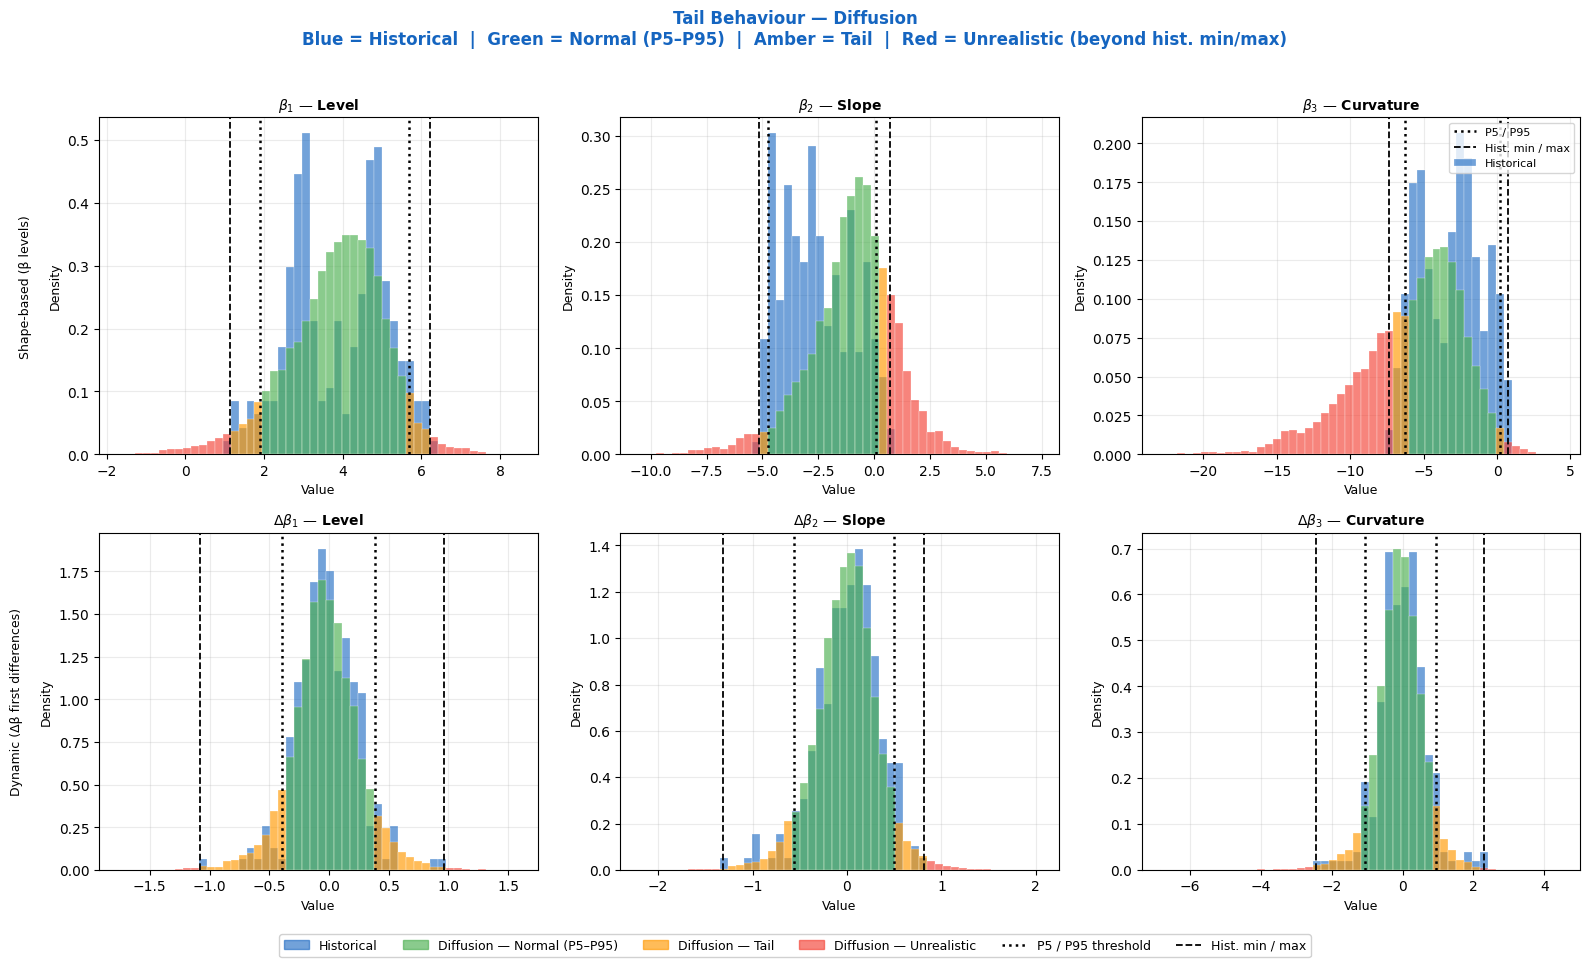

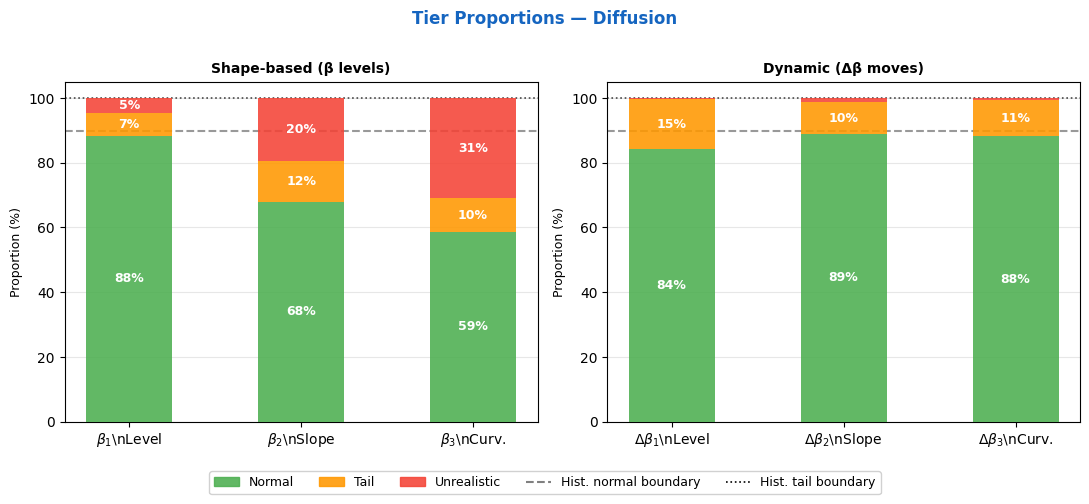

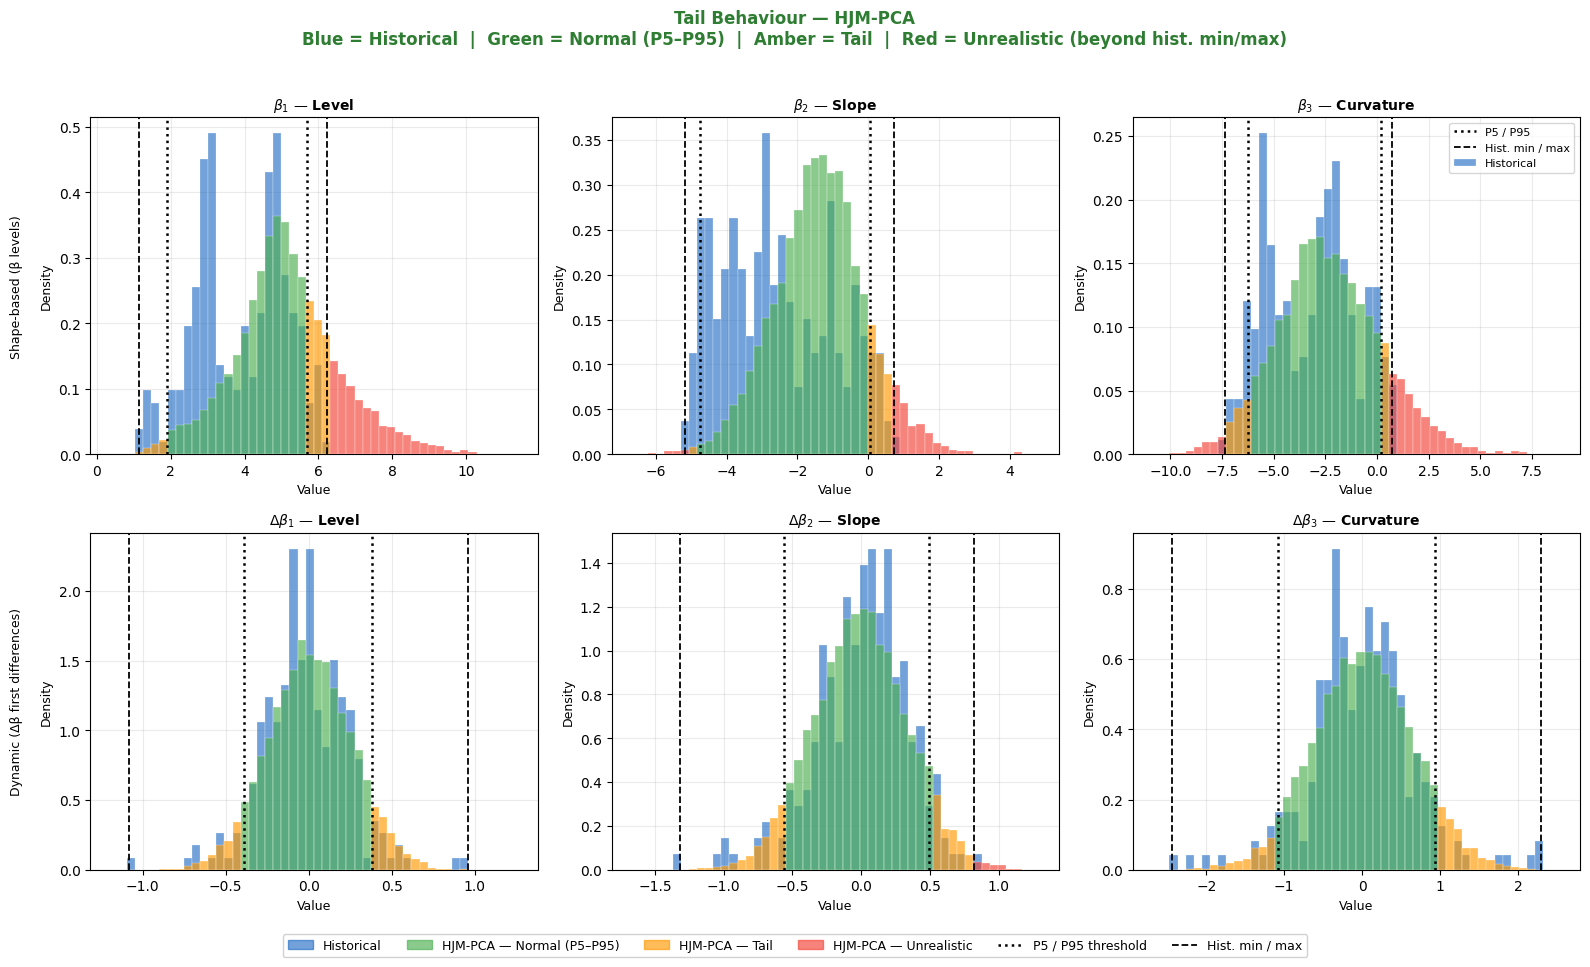

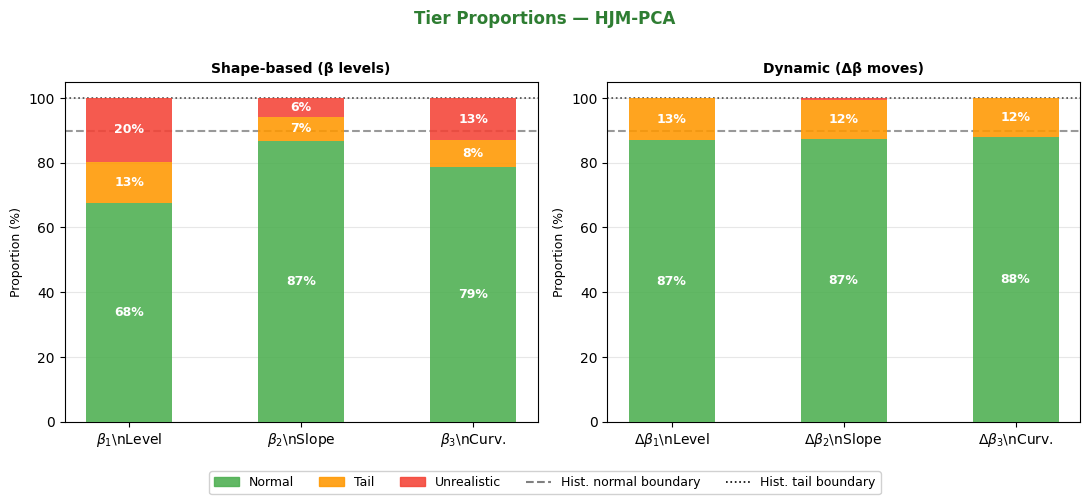

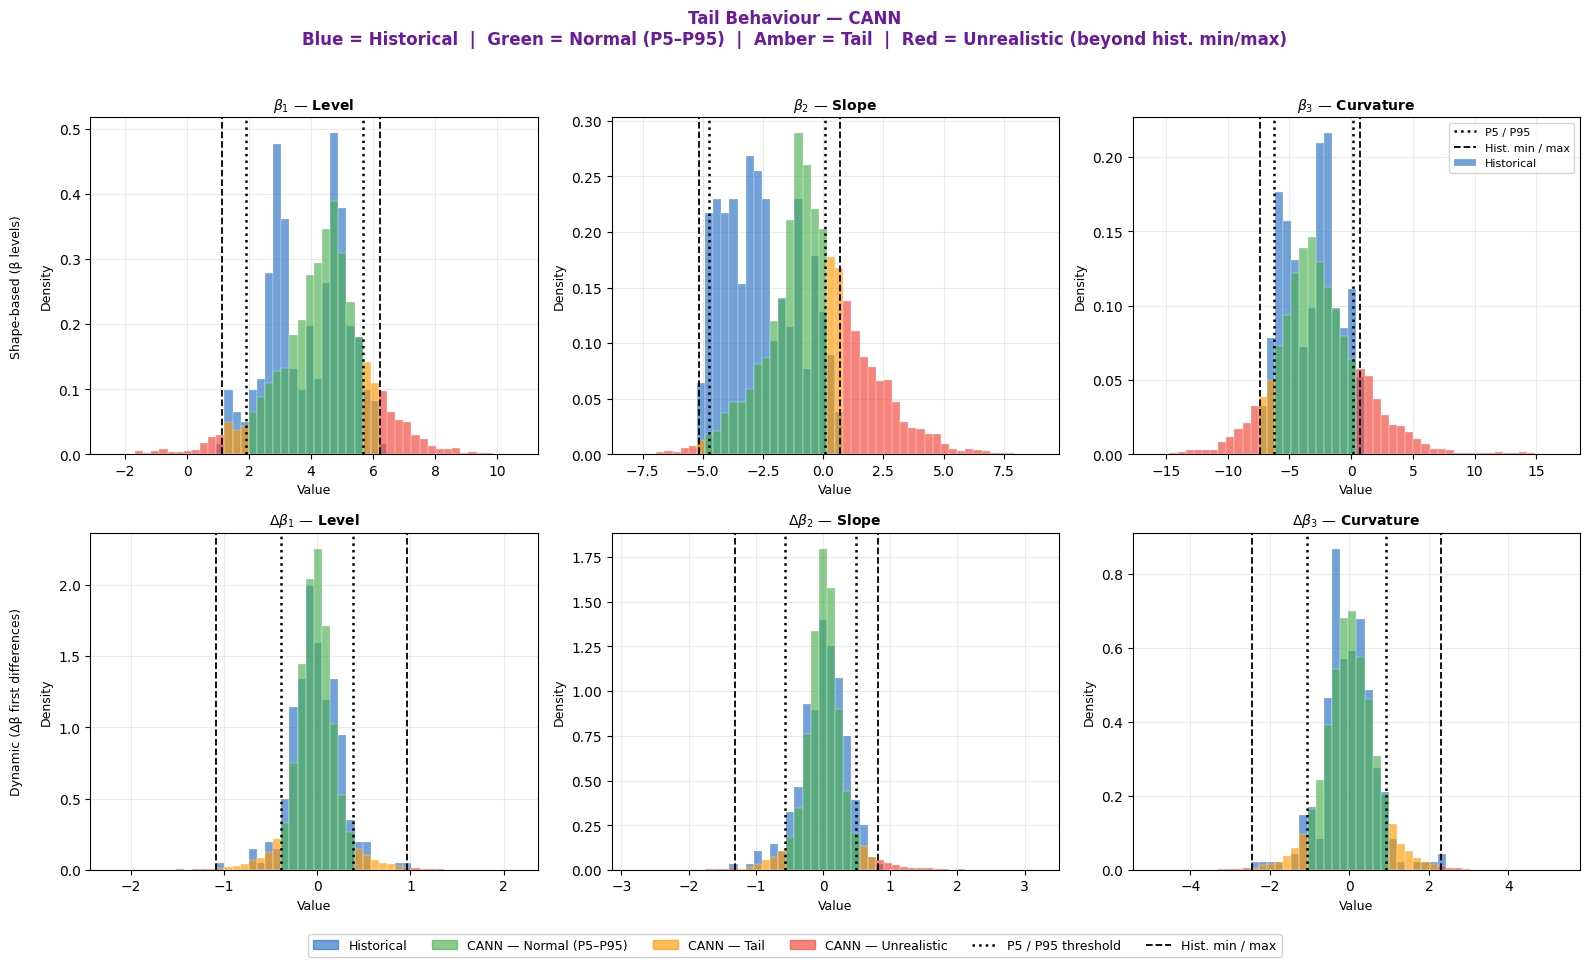

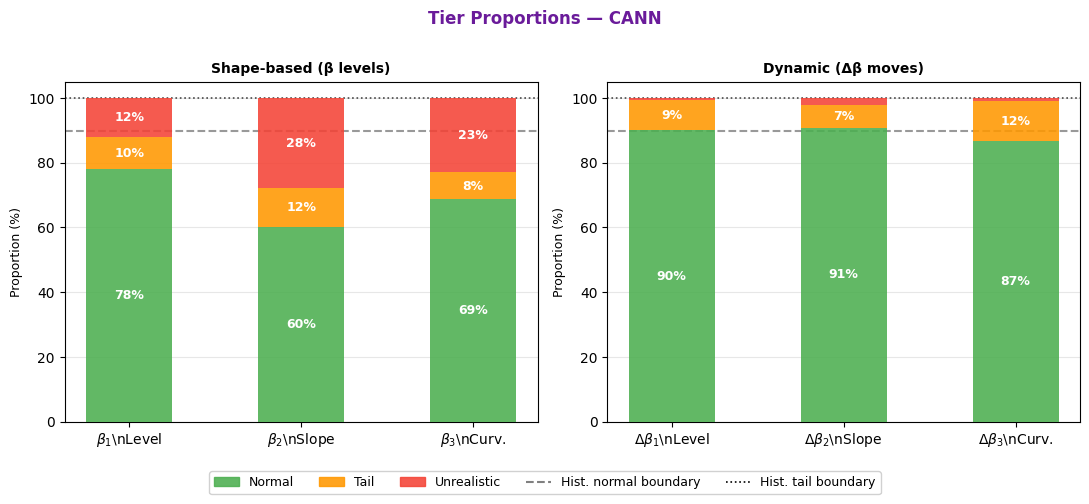

In [258]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.7  Tail Behaviour — histograms + proportion bars
# Historical bars: solid blue | Model bars: coloured by zone
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

HIST_YLD_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                 "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_YLD_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                 "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]

C_HIST        = "#1565C0"   # blue — historical bars
C_NORMAL      = "#4CAF50"   # green — model: normal zone
C_TAIL        = "#FF9800"   # amber — model: tail zone
C_UNREALISTIC = "#F44336"   # red   — model: unrealistic zone

_MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}

FACTOR_LABELS = [r"$\beta_1$ — Level", r"$\beta_2$ — Slope", r"$\beta_3$ — Curvature"]
DIFF_LABELS   = [r"$\Delta\beta_1$ — Level", r"$\Delta\beta_2$ — Slope", r"$\Delta\beta_3$ — Curvature"]
TIER_COLORS   = {"Normal": C_NORMAL, "Tail": C_TAIL, "Unrealistic": C_UNREALISTIC}
TIER_ORDER    = ["Normal", "Tail", "Unrealistic"]
N_BINS        = 50


def plot_hist_pair(ax, hist_vals, sim_vals, t_lo, t_hi, v_min, v_max):
    """
    Historical: all blue bars.
    Model: bars coloured green/amber/red depending on which zone the bin centre falls in.
    Vertical lines mark P5/P95 (dotted) and historical min/max (dashed).
    """
    lo = min(hist_vals.min(), sim_vals.min())
    hi = max(hist_vals.max(), sim_vals.max())
    pad = 0.05 * (hi - lo)
    edges = np.linspace(lo - pad, hi + pad, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]

    # Historical — all blue
    h_counts, _ = np.histogram(hist_vals, bins=edges, density=True)
    ax.bar(centers, h_counts, width=width,
           color=C_HIST, alpha=0.6, edgecolor="white", linewidth=0.3,
           zorder=2, label="Historical")

    # Model — coloured by zone
    s_counts, _ = np.histogram(sim_vals, bins=edges, density=True)
    for c, count in zip(centers, s_counts):
        if c < v_min or c > v_max:
            color = C_UNREALISTIC
        elif c < t_lo or c > t_hi:
            color = C_TAIL
        else:
            color = C_NORMAL
        ax.bar(c, count, width=width, color=color, alpha=0.65,
               edgecolor="white", linewidth=0.3, zorder=3)

    # Threshold lines
    ax.axvline(t_lo,  color="black", ls=":",  lw=1.8, zorder=5, label="P5 / P95")
    ax.axvline(t_hi,  color="black", ls=":",  lw=1.8, zorder=5)
    ax.axvline(v_min, color="black", ls="--", lw=1.3, zorder=5, label="Hist. min / max")
    ax.axvline(v_max, color="black", ls="--", lw=1.3, zorder=5)

    ax.set_ylabel("Density", fontsize=9)
    ax.grid(alpha=0.25, zorder=0)
    ax.set_axisbelow(True)


def dist_plot_for_model(name, betas_flat, betas_sc):
    diffs_flat = np.diff(betas_sc, axis=1).reshape(-1, 3)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(
        f"Tail Behaviour — {name}\n"
        "Blue = Historical  |  Green = Normal (P5–P95)  |  Amber = Tail  |  Red = Unrealistic (beyond hist. min/max)",
        fontsize=12, fontweight="bold", color=_MODEL_COLORS[name], y=1.02
    )

    for row, (hist_vals, sim_vals, thresholds, labels, row_label) in enumerate([
        (hist_betas_ts, betas_flat,
         [(shape_tail_lo[i], shape_tail_hi[i], shape_min[i], shape_max[i]) for i in range(3)],
         FACTOR_LABELS, "Shape-based (β levels)"),
        (hist_diff_ts, diffs_flat,
         [(dyn_tail_lo[i], dyn_tail_hi[i], dyn_min[i], dyn_max[i]) for i in range(3)],
         DIFF_LABELS, "Dynamic (Δβ first differences)"),
    ]):
        for col in range(3):
            ax = axes[row, col]
            t_lo, t_hi, v_min, v_max = thresholds[col]
            plot_hist_pair(ax, hist_vals[:, col], sim_vals[:, col],
                           t_lo, t_hi, v_min, v_max)
            ax.set_title(labels[col], fontsize=10, fontweight="bold")
            ax.set_xlabel("Value", fontsize=9)
            if col == 0:
                ax.set_ylabel(f"{row_label}\n\nDensity", fontsize=9)
            if row == 0 and col == 2:
                ax.legend(fontsize=8, loc="upper right")

    legend_patches = [
        mpatches.Patch(color=C_HIST,        alpha=0.6,  label="Historical"),
        mpatches.Patch(color=C_NORMAL,      alpha=0.65, label=f"{name} — Normal (P5–P95)"),
        mpatches.Patch(color=C_TAIL,        alpha=0.65, label=f"{name} — Tail"),
        mpatches.Patch(color=C_UNREALISTIC, alpha=0.65, label=f"{name} — Unrealistic"),
        plt.Line2D([0],[0], color="black", ls=":",  lw=1.8, label="P5 / P95 threshold"),
        plt.Line2D([0],[0], color="black", ls="--", lw=1.3, label="Hist. min / max"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=6,
               fontsize=9, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
    plt.tight_layout()
    plt.show()


def prop_bar_plot(name, results):
    fig, (ax_s, ax_d) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(f"Tier Proportions — {name}",
                 fontsize=12, fontweight="bold", color=_MODEL_COLORS[name], y=1.01)

    for ax, kind, xlabels, ref_n, ref_t in [
        (ax_s, "shape",
         [r"$\beta_1$\nLevel", r"$\beta_2$\nSlope", r"$\beta_3$\nCurv."],
         np.mean([tail_results["Historical"]["shape"][i][0] for i in range(3)]),
         np.mean([tail_results["Historical"]["shape"][i][1] for i in range(3)])),
        (ax_d, "dyn",
         [r"$\Delta\beta_1$\nLevel", r"$\Delta\beta_2$\nSlope", r"$\Delta\beta_3$\nCurv."],
         np.mean([tail_results["Historical"]["dyn"][i][0] for i in range(3)]),
         np.mean([tail_results["Historical"]["dyn"][i][1] for i in range(3)])),
    ]:
        x = np.arange(3)
        bottoms = np.zeros(3)
        for tier in TIER_ORDER:
            idx = TIER_ORDER.index(tier)
            vals = np.array([results[kind][i][idx] * 100 for i in range(3)])
            ax.bar(x, vals, 0.5, bottom=bottoms,
                   color=TIER_COLORS[tier], alpha=0.88, zorder=3)
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v >= 3:
                    ax.text(xi, b + v/2, f"{v:.0f}%",
                            ha="center", va="center", fontsize=9,
                            fontweight="bold", color="white")
            bottoms += vals

        ax.axhline(ref_n * 100, color="grey", ls="--", lw=1.5, alpha=0.8)
        ax.axhline((ref_n + ref_t) * 100, color="black", ls=":", lw=1.2, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Proportion (%)", fontsize=9)
        ax.yaxis.grid(True, alpha=0.3, zorder=0)
        ax.set_axisbelow(True)

    ax_s.set_title("Shape-based (β levels)", fontsize=10, fontweight="bold")
    ax_d.set_title("Dynamic (Δβ moves)", fontsize=10, fontweight="bold")

    patches = [mpatches.Patch(color=TIER_COLORS[t], label=t, alpha=0.88) for t in TIER_ORDER]
    patches += [plt.Line2D([0],[0], color="grey", ls="--", lw=1.5, label="Hist. normal boundary"),
                plt.Line2D([0],[0], color="black", ls=":", lw=1.2, label="Hist. tail boundary")]
    fig.legend(handles=patches, loc="lower center", ncol=5,
               fontsize=9, bbox_to_anchor=(0.5, -0.08), framealpha=0.9)
    plt.tight_layout()
    plt.show()


# ── Run for all models ────────────────────────────────────────────────────────
for name, path in MODELS.items():
    tensor     = scenario_tensor(path)
    betas_flat = fit_betas(tensor.reshape(-1, 11))
    betas_sc   = np.stack([fit_betas(tensor[s]) for s in range(tensor.shape[0])])
    dist_plot_for_model(name, betas_flat, betas_sc)
    prop_bar_plot(name, tail_results[name])


In [259]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.7  Tail Behaviour — Summary Table
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

factor_short = ["β1 (Level)", "β2 (Slope)", "β3 (Curvature)"]
tier_names   = ["Normal", "Tail", "Unrealistic"]
all_models   = ["Historical"] + list(MODELS.keys())

rows = []
for analysis, kind in [("Shape-based", "shape"), ("Dynamic", "dyn")]:
    for fi, fname in enumerate(factor_short):
        for model in all_models:
            n, t, u = tail_results[model][kind][fi]
            rows.append({
                "Analysis":     analysis,
                "Factor":       fname,
                "Model":        model,
                "Normal (%)":   round(n * 100, 1),
                "Tail (%)":     round(t * 100, 1),
                "Unrealistic (%)": round(u * 100, 1),
            })

df_tail = pd.DataFrame(rows)

for analysis in ["Shape-based", "Dynamic"]:
    print(f"\n{'='*70}")
    print(f"  {analysis} tail proportions")
    print(f"  (Historical = benchmark: ~90% normal, ~10% tail, 0% unrealistic)")
    print(f"{'='*70}")
    sub = df_tail[df_tail["Analysis"] == analysis].drop(columns="Analysis")
    pivot = sub.set_index(["Factor","Model"])
    print(pivot.to_string())

# ── Compact unrealistic-only summary (most actionable number) ────────────────
print(f"\n{'='*70}")
print("  UNREALISTIC proportions only (% of observations beyond historical min/max)")
print(f"{'='*70}")
unreal_rows = []
for analysis, kind in [("Shape", "shape"), ("Dynamic", "dyn")]:
    for model in all_models:
        row = {"Analysis": analysis, "Model": model}
        for fi, fname in enumerate(factor_short):
            _, _, u = tail_results[model][kind][fi]
            row[fname] = f"{u*100:.1f}%"
        unreal_rows.append(row)

df_unreal = pd.DataFrame(unreal_rows).set_index(["Analysis","Model"])
print(df_unreal.to_string())



  Shape-based tail proportions
  (Historical = benchmark: ~90% normal, ~10% tail, 0% unrealistic)
                           Normal (%)  Tail (%)  Unrealistic (%)
Factor         Model                                            
β1 (Level)     Historical      89.700    10.300            0.000
               Diffusion       88.200     7.100            4.700
               HJM-PCA         67.600    12.600           19.700
               CANN            77.900     9.800           12.200
β2 (Slope)     Historical      89.700    10.300            0.000
               Diffusion       67.900    12.400           19.700
               HJM-PCA         86.800     7.400            5.800
               CANN            60.100    11.900           28.000
β3 (Curvature) Historical      89.700    10.300            0.000
               Diffusion       58.600    10.500           30.900
               HJM-PCA         78.800     8.200           13.100
               CANN            68.600     8.400         

## 4.9 Diversity

Diversity is assessed by extracting three financially interpretable features from every yield curve observation and measuring how widely the generated scenarios span each dimension:

- **Level** = average yield across all 11 maturities — captures parallel shifts
- **Slope** = 30Y yield − 3M yield — captures whether the curve is upward-sloping, flat, or inverted
- **Curvature** = 10Y − 0.5 × (3M + 30Y) — captures hump-shaped or U-shaped structures

High standard deviation and wide range across features indicate diverse scenario coverage. Very small dispersion signals mode collapse.

Historical: 232 monthly yield curves
  Diffusion   : 12,000 yield curve observations
  HJM-PCA     : 12,000 yield curve observations
  CANN        : 12,000 yield curve observations


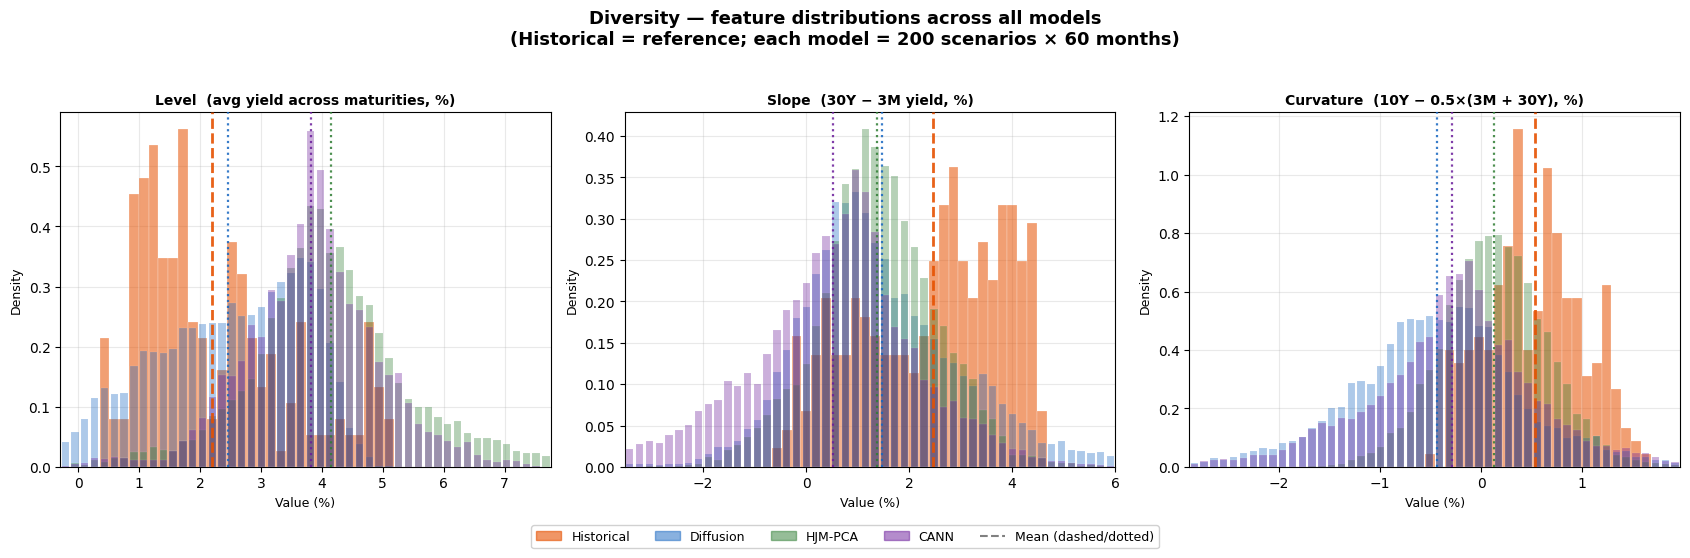

In [260]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.9  Diversity — feature extraction and distribution plots
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

HIST_YLD_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                 "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_YLD_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                 "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]

_MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}
HIST_COLOR = "#E65100"
N_BINS     = 50

# ── Feature extraction ────────────────────────────────────────────────────────
def extract_features(df, col_3m, col_10y, col_30y, all_cols):
    """Level / Slope / Curvature for every row of df."""
    Y = df[all_cols].values
    level     = Y.mean(axis=1)
    slope     = df[col_30y].values - df[col_3m].values
    curvature = df[col_10y].values - 0.5 * (df[col_3m].values + df[col_30y].values)
    return pd.DataFrame({"Level": level, "Slope": slope, "Curvature": curvature})

# Historical
hist_feat = extract_features(hist_monthly,
                             "Yield_3M", "Yield_10Y", "Yield_30Y",
                             HIST_YLD_COLS)
print(f"Historical: {len(hist_feat)} monthly yield curves")

# All models
sim_feat = {}
for name, path in MODELS.items():
    df = load_scenarios(path)
    sim_feat[name] = extract_features(df, "Y_3M", "Y_10Y", "Y_30Y", SIM_YLD_COLS)
    print(f"  {name:12s}: {len(sim_feat[name]):,} yield curve observations")

# ── Distribution plots — one panel per feature, all models overlaid ───────────
FEAT_LABELS = {
    "Level":     "Level  (avg yield across maturities, %)",
    "Slope":     "Slope  (30Y − 3M yield, %)",
    "Curvature": "Curvature  (10Y − 0.5×(3M + 30Y), %)",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Diversity — feature distributions across all models\n"
    "(Historical = reference; each model = 200 scenarios × 60 months)",
    fontsize=13, fontweight="bold", y=1.03,
)

for ax, feature in zip(axes, ["Level", "Slope", "Curvature"]):

    # Shared bin range across all datasets
    all_vals = np.concatenate(
        [hist_feat[feature].values] +
        [f[feature].values for f in sim_feat.values()]
    )
    lo, hi = np.percentile(all_vals, 0.5), np.percentile(all_vals, 99.5)
    edges  = np.linspace(lo, hi, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width   = edges[1] - edges[0]

    # Historical — blue, slightly wider bars so it reads as background
    h_counts, _ = np.histogram(hist_feat[feature].values, bins=edges, density=True)
    ax.bar(centers, h_counts, width=width * 1.0,
           color=HIST_COLOR, alpha=0.55, label="Historical",
           edgecolor="white", linewidth=0.3, zorder=2)

    # Each model — semi-transparent step histogram
    for name, feat_df in sim_feat.items():
        s_counts, _ = np.histogram(feat_df[feature].values, bins=edges, density=True)
        ax.bar(centers, s_counts, width=width * 0.75,
               color=_MODEL_COLORS[name], alpha=0.35,
               edgecolor="white", linewidth=0.2, zorder=3, label=name)

    # Mean lines
    ax.axvline(hist_feat[feature].mean(), color=HIST_COLOR,
               ls="--", lw=2.0, alpha=0.9, zorder=5)
    for name, feat_df in sim_feat.items():
        ax.axvline(feat_df[feature].mean(), color=_MODEL_COLORS[name],
                   ls=":", lw=1.6, alpha=0.85, zorder=5)

    ax.set_xlim(lo, hi)
    ax.set_title(FEAT_LABELS[feature], fontsize=10, fontweight="bold")
    ax.set_xlabel("Value (%)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.grid(alpha=0.28, zorder=0)
    ax.set_axisbelow(True)

# Shared legend
handles = [mpatches.Patch(color=HIST_COLOR, alpha=0.6, label="Historical")]
handles += [mpatches.Patch(color=_MODEL_COLORS[n], alpha=0.5, label=n)
            for n in MODELS]
handles += [plt.Line2D([0],[0], color="grey", ls="--", lw=1.5, label="Mean (dashed/dotted)")]
fig.legend(handles=handles, loc="lower center", ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.06), framealpha=0.9)
plt.tight_layout()
plt.show()


In [261]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.9  Diversity — summary table  (Mean, Std Dev, Min, Max, Range)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

features  = ["Level", "Slope", "Curvature"]
stats_lbl = ["Mean", "Std Dev", "Min", "Max", "Range"]

all_datasets = {"Historical": hist_feat, **sim_feat}

rows = []
for name, feat_df in all_datasets.items():
    for feat in features:
        v = feat_df[feat].values
        rows.append({
            "Model":   name,
            "Feature": feat,
            "Mean":    round(v.mean(), 3),
            "Std Dev": round(v.std(),  3),
            "Min":     round(v.min(),  3),
            "Max":     round(v.max(),  3),
            "Range":   round(v.max() - v.min(), 3),
        })

div_df = pd.DataFrame(rows).set_index(["Model", "Feature"])

print("=" * 72)
print("  Diversity Summary — Level / Slope / Curvature")
print("  Higher Std Dev and Range = more diverse scenario coverage")
print("=" * 72)
print(div_df.to_string())

# ── Compact ranking table by Std Dev (most readable for thesis) ───────────────
print("\n" + "=" * 55)
print("  Std Dev ranking per feature  (higher = more diverse)")
print("=" * 55)
pivot_std = (div_df["Std Dev"]
             .unstack("Feature")[features]
             .rename_axis(None, axis=1))
pivot_std["Avg Std Dev"] = pivot_std.mean(axis=1)
pivot_std = pivot_std.sort_values("Avg Std Dev", ascending=False)
print(pivot_std.round(3).to_string())

print("\n" + "=" * 55)
print("  Range ranking per feature  (higher = more diverse)")
print("=" * 55)
pivot_range = (div_df["Range"]
               .unstack("Feature")[features]
               .rename_axis(None, axis=1))
pivot_range["Avg Range"] = pivot_range.mean(axis=1)
pivot_range = pivot_range.sort_values("Avg Range", ascending=False)
print(pivot_range.round(3).to_string())


  Diversity Summary — Level / Slope / Curvature
  Higher Std Dev and Range = more diverse scenario coverage
                       Mean  Std Dev    Min    Max  Range
Model      Feature                                       
Historical Level      2.200    1.226  0.358  5.105  4.746
           Slope      2.466    1.379 -0.480  4.600  5.080
           Curvature  0.537    0.466 -0.475  1.605  2.080
Diffusion  Level      2.458    1.253 -2.467  5.049  7.516
           Slope      1.469    1.643 -4.253  9.027 13.281
           Curvature -0.437    0.882 -4.023  2.806  6.829
HJM-PCA    Level      4.146    1.358 -0.161 10.482 10.643
           Slope      1.386    1.157 -4.137  5.718  9.855
           Curvature  0.132    0.516 -1.771  2.210  3.982
CANN       Level      3.826    1.101 -0.607  7.649  8.256
           Slope      0.519    1.645 -6.459  6.060 12.519
           Curvature -0.290    0.856 -3.769  2.973  6.741

  Std Dev ranking per feature  (higher = more diverse)
            Level  Slope

### Novelty


  NOVELTY EVALUATION

[1] Loading data...
  Historical: 232 monthly obs → 173 rolling windows of 60
  Scenarios: 200 scenarios × 60 timesteps × 11 maturities
  Scenarios: 500 scenarios × 60 timesteps × 11 maturities

[2] Calibrating thresholds (historical nearest-neighbour distances)...

  Historical nearest-neighbour distance distribution:
    P 5: 0.0736 pp
    P10: 0.1220 pp
    P25: 0.1696 pp
    P50: 0.2666 pp
    P75: 0.3811 pp
    P90: 0.5406 pp
    P95: 0.6452 pp
    P99: 1.0463 pp
    Mean: 0.3043 pp  |  Std: 0.1951 pp

  → Current thresholds:  lower=0.5  upper=4.0

[3] Computing min distances to historical set...
  Historical windows: 10380 obs
  MVP1: 12000 obs
  HJM-PCA: 30000 obs

[4] Classifying observations...

[5] Computing per-scenario novelty frequencies...
  Historical windows:
  MVP1:
  HJM-PCA:

[6] Building summary tables...

  OBSERVATION-LEVEL NOVELTY  (lower=0.5, upper=4.0)
  All timestep observations pooled across scenarios
            Not Novel (%)  Novel (%

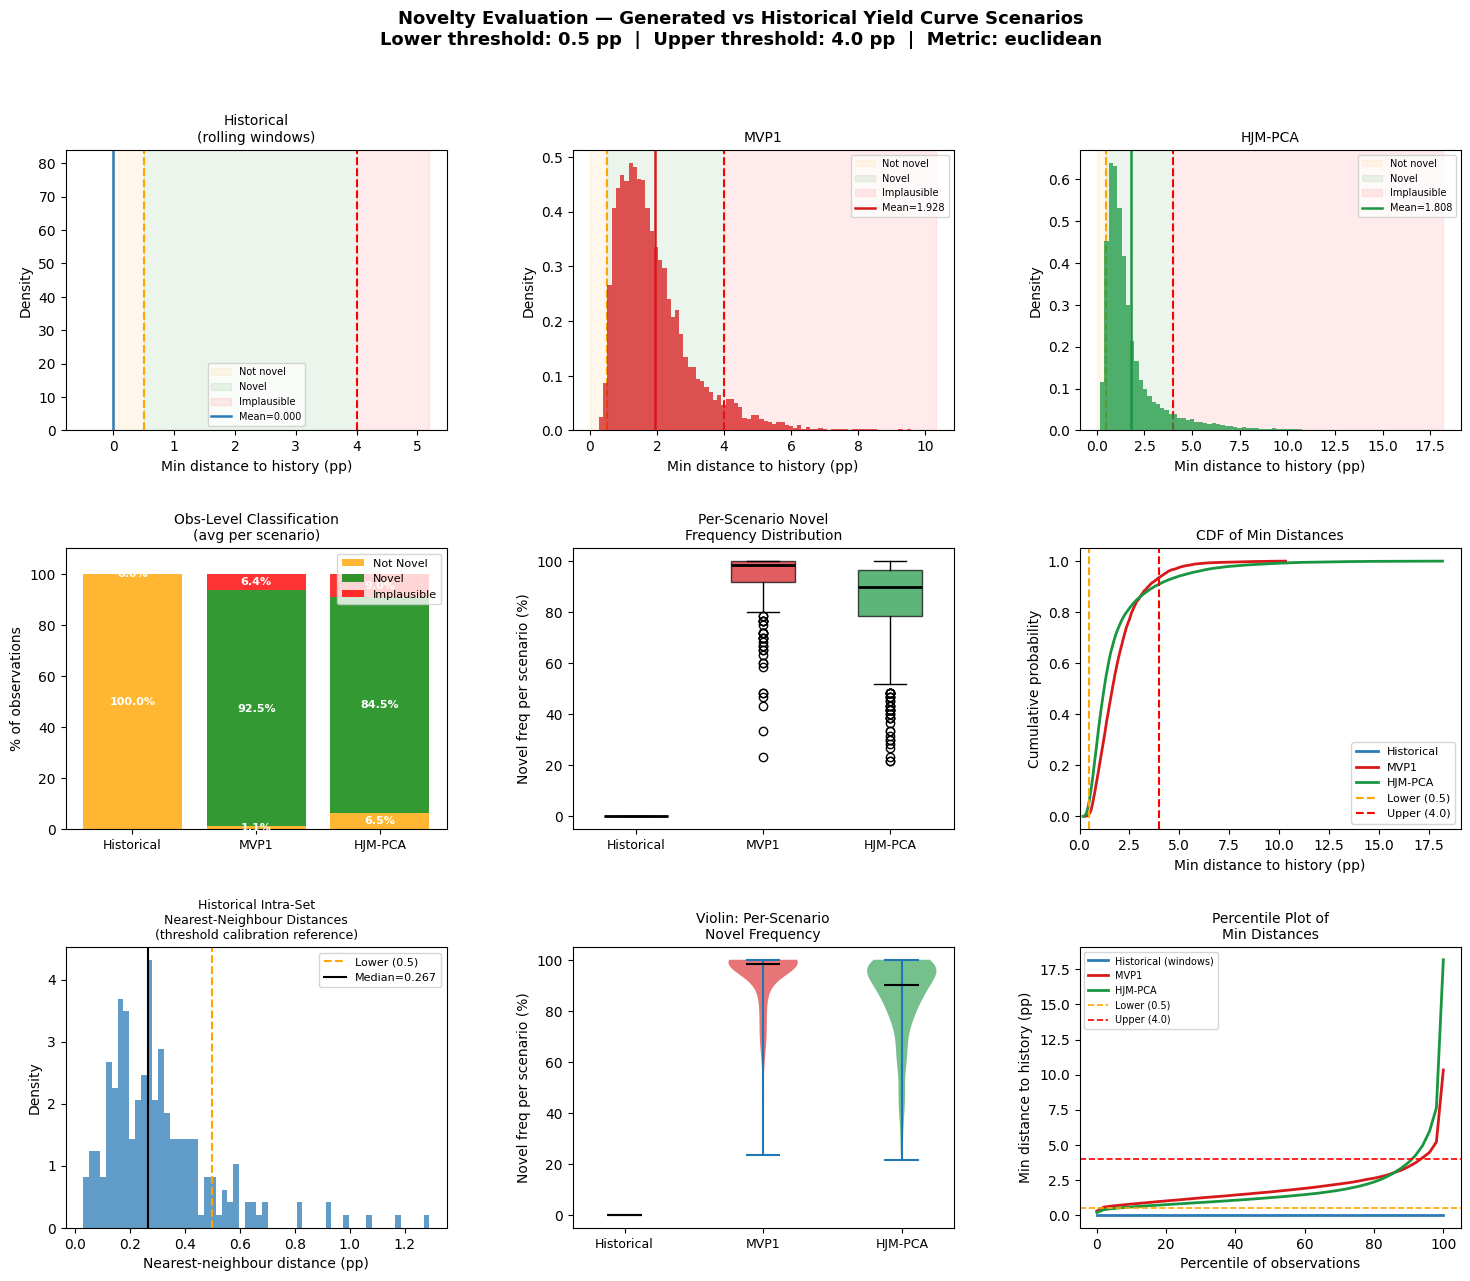


✓ Novelty evaluation complete.


In [262]:
"""
Novelty Evaluation
==================
Assesses the novelty of generated yield curve scenarios (MVP1 and HJM-PCA)
relative to the historical dataset, following Section 4.7 (Novelty) of the
thesis methodology.

A generated yield curve observation is classified as:
  - Too close   : min_distance < NOVELTY_LOWER_THRESHOLD  (not novel, replicates history)
  - Novel       : NOVELTY_LOWER_THRESHOLD <= min_distance <= NOVELTY_UPPER_THRESHOLD
  - Implausible : min_distance > NOVELTY_UPPER_THRESHOLD  (too far from history)

Distances are computed as the Euclidean distance between yield curve vectors
(in percentage points, across all 11 maturities).

Author: Thesis evaluation pipeline
"""

import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIGURABLE PARAMETERS
# ─────────────────────────────────────────────

# Distance thresholds (Euclidean, in percentage points across 11 maturities)
# Lower: below this → not novel (too similar to history)
# Upper: above this → implausible (too far from history)
# Calibrated on the observed historical pairwise distance distribution:
#   typical neighbour distances range ~0.3 to ~4.0 pp
NOVELTY_LOWER_THRESHOLD = 0.50   # pp  — adjust as needed
NOVELTY_UPPER_THRESHOLD = 4.00   # pp  — adjust as needed

DISTANCE_METRIC = "euclidean"    # distance metric for cdist

# Maturity labels (must match column order in all CSVs)
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]


# ─────────────────────────────────────────────
# DATA LOADING  (reusing same logic as tail_evaluation.py)
# ─────────────────────────────────────────────

def load_historical(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load daily historical data, resample to month-end, extract yield columns.
    Returns:
        yields_monthly : (n_months, 11)  – used as reference set
        rolling_windows: (n_windows, 60, 11) – comparable 60-step windows
    """
    df = pd.read_csv(path, parse_dates=["DATE"], dayfirst=False)
    df = df.set_index("DATE").sort_index()
    yield_cols = [f"Yield_{m}" for m in MATURITY_LABELS]
    yields_monthly = df[yield_cols].dropna().resample("ME").last().dropna().values

    # Build rolling windows of 60 timesteps (shift by 1 each time)
    W = 60
    n = len(yields_monthly)
    windows = np.stack([yields_monthly[s:s+W] for s in range(n - W + 1)])
    print(f"  Historical: {n} monthly obs → {len(windows)} rolling windows of {W}")
    return yields_monthly, windows   # (n_months,11) and (n_windows,60,11)


def load_scenarios(path: str) -> np.ndarray:
    """
    Load generated scenario CSV.
    Returns array of shape (n_scenarios, n_timesteps, n_maturities).
    """
    df = pd.read_csv(path)
    yield_cols = [f"Y_{m}" for m in MATURITY_LABELS]
    n_scen  = df["Scenario_ID"].nunique()
    n_steps = df.groupby("Scenario_ID").size().iloc[0]
    arr = (df.sort_values(["Scenario_ID","Month"])[yield_cols]
             .values
             .reshape(n_scen, n_steps, len(MATURITY_LABELS)))
    print(f"  Scenarios: {n_scen} scenarios × {n_steps} timesteps × {len(MATURITY_LABELS)} maturities")
    return arr


# ─────────────────────────────────────────────
# DISTANCE COMPUTATION
# ─────────────────────────────────────────────

def min_distance_to_history(generated_obs: np.ndarray,
                             historical_obs: np.ndarray,
                             metric: str = DISTANCE_METRIC) -> np.ndarray:
    """
    For each generated yield curve observation, compute the minimum Euclidean
    distance to any yield curve in the historical dataset.

    generated_obs : (N, 11)  – all generated observations (flattened across scenarios)
    historical_obs: (M, 11)  – all historical monthly observations
    Returns       : (N,)     – min distance for each generated observation
    """
    # cdist returns (N, M); take row-wise min
    D = cdist(generated_obs, historical_obs, metric=metric)
    return D.min(axis=1)   # (N,)


def classify_observations(min_dists: np.ndarray,
                           lower: float = NOVELTY_LOWER_THRESHOLD,
                           upper: float = NOVELTY_UPPER_THRESHOLD
                           ) -> dict:
    """
    Classify each observation as not-novel, novel, or implausible.
    Returns dict with boolean masks and summary proportions.
    """
    not_novel   = min_dists < lower
    novel       = (min_dists >= lower) & (min_dists <= upper)
    implausible = min_dists > upper

    n = len(min_dists)
    return {
        "not_novel_mask":   not_novel,
        "novel_mask":       novel,
        "implausible_mask": implausible,
        "pct_not_novel":    not_novel.mean()   * 100,
        "pct_novel":        novel.mean()       * 100,
        "pct_implausible":  implausible.mean() * 100,
        "mean_min_dist":    min_dists.mean(),
        "median_min_dist":  np.median(min_dists),
        "p5_min_dist":      np.percentile(min_dists, 5),
        "p95_min_dist":     np.percentile(min_dists, 95),
        "n_obs":            n,
    }


# ─────────────────────────────────────────────
# SCENARIO-LEVEL NOVELTY
# ─────────────────────────────────────────────

def scenario_novelty_freq(scenarios: np.ndarray,
                           historical_obs: np.ndarray,
                           lower: float = NOVELTY_LOWER_THRESHOLD,
                           upper: float = NOVELTY_UPPER_THRESHOLD
                           ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For each scenario, compute the proportion of its timestep observations
    that are classified as novel, not-novel, and implausible.

    scenarios     : (n_scenarios, n_timesteps, 11)
    historical_obs: (M, 11)
    Returns three arrays of shape (n_scenarios,): novel_freq, not_novel_freq, implausible_freq
    """
    n_scen, n_steps, n_mat = scenarios.shape
    novel_freq       = np.zeros(n_scen)
    not_novel_freq   = np.zeros(n_scen)
    implausible_freq = np.zeros(n_scen)

    for i in range(n_scen):
        obs = scenarios[i]   # (n_steps, 11)
        dists = min_distance_to_history(obs, historical_obs)
        cl = classify_observations(dists, lower, upper)
        novel_freq[i]       = cl["pct_novel"]
        not_novel_freq[i]   = cl["pct_not_novel"]
        implausible_freq[i] = cl["pct_implausible"]

    return novel_freq, not_novel_freq, implausible_freq


def window_novelty_freq(windows: np.ndarray,
                         historical_obs: np.ndarray,
                         lower: float = NOVELTY_LOWER_THRESHOLD,
                         upper: float = NOVELTY_UPPER_THRESHOLD
                         ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Same as scenario_novelty_freq but for historical rolling windows.
    Each window is compared against the FULL historical set (including itself),
    giving a baseline of how often historical obs are "novel" to themselves.

    windows       : (n_windows, 60, 11)
    historical_obs: (M, 11)
    """
    n_windows = len(windows)
    novel_freq       = np.zeros(n_windows)
    not_novel_freq   = np.zeros(n_windows)
    implausible_freq = np.zeros(n_windows)

    for i in range(n_windows):
        obs = windows[i]   # (60, 11)
        dists = min_distance_to_history(obs, historical_obs)
        cl = classify_observations(dists, lower, upper)
        novel_freq[i]       = cl["pct_novel"]
        not_novel_freq[i]   = cl["pct_not_novel"]
        implausible_freq[i] = cl["pct_implausible"]

    return novel_freq, not_novel_freq, implausible_freq


# ─────────────────────────────────────────────
# CALIBRATION HELPER
# ─────────────────────────────────────────────

def calibrate_thresholds(historical_obs: np.ndarray, sample_size: int = 500):
    """
    Print pairwise distance percentiles within the historical dataset to help
    the user calibrate NOVELTY_LOWER_THRESHOLD and NOVELTY_UPPER_THRESHOLD.
    Uses a random subsample for efficiency if the dataset is large.
    """
    n = len(historical_obs)
    if n > sample_size:
        idx = np.random.choice(n, sample_size, replace=False)
        sample = historical_obs[idx]
    else:
        sample = historical_obs

    D = cdist(sample, sample, metric=DISTANCE_METRIC)
    # Zero out diagonal (self-distances)
    np.fill_diagonal(D, np.inf)
    nn_dists = D.min(axis=1)   # nearest-neighbour distances within history

    print("\n  Historical nearest-neighbour distance distribution:")
    for p in [5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"    P{p:2d}: {np.percentile(nn_dists, p):.4f} pp")
    print(f"    Mean: {nn_dists.mean():.4f} pp  |  Std: {nn_dists.std():.4f} pp")
    print(f"\n  → Current thresholds:  lower={NOVELTY_LOWER_THRESHOLD}  "
          f"upper={NOVELTY_UPPER_THRESHOLD}")
    return nn_dists


# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────

def build_summary_table(results: dict) -> pd.DataFrame:
    """
    Build a comparison table of novelty metrics across models.
    results: dict keyed by model name, each containing classify_observations output
    """
    rows = {}
    for model, r in results.items():
        rows[model] = {
            "Not Novel (%)":   r["pct_not_novel"],
            "Novel (%)":       r["pct_novel"],
            "Implausible (%)": r["pct_implausible"],
            "Mean min dist":   r["mean_min_dist"],
            "Median min dist": r["median_min_dist"],
            "P5 min dist":     r["p5_min_dist"],
            "P95 min dist":    r["p95_min_dist"],
        }
    return pd.DataFrame(rows).T


def build_scenario_table(
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
) -> pd.DataFrame:
    """Summary table of per-scenario novelty frequencies."""
    def row(novel, not_novel, implausible):
        return {
            "Mean novel (%)":       novel.mean(),
            "Std novel (%)":        novel.std(),
            "Median novel (%)":     np.median(novel),
            "P5 novel (%)":         np.percentile(novel, 5),
            "P95 novel (%)":        np.percentile(novel, 95),
            "Mean implausible (%)": implausible.mean(),
        }
    return pd.DataFrame({
        "Historical": row(hist_novel, hist_not_novel, hist_implausible),
        "MVP1":       row(mvp1_novel, mvp1_not_novel, mvp1_implausible),
        "HJM-PCA":   row(hjm_novel,  hjm_not_novel,  hjm_implausible),
    }).T


def print_tables(obs_table, scen_table):
    pd.set_option("display.float_format", "{:.3f}".format)
    print("\n" + "="*70)
    print("  OBSERVATION-LEVEL NOVELTY  "
          f"(lower={NOVELTY_LOWER_THRESHOLD}, upper={NOVELTY_UPPER_THRESHOLD})")
    print("  All timestep observations pooled across scenarios")
    print("="*70)
    print(obs_table.to_string())

    print("\n" + "="*70)
    print("  SCENARIO-LEVEL NOVELTY  (per-scenario mean novelty freq)")
    print("="*70)
    print(scen_table.to_string())


# ─────────────────────────────────────────────
# STATISTICAL TESTS
# ─────────────────────────────────────────────

def t_test(a: np.ndarray, b: np.ndarray, label_a: str, label_b: str) -> dict:
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    D = b.mean() - a.mean()
    return {
        "D (B−A, %)": D,
        "t-statistic": t_stat,
        "p-value":     p_val,
        "Significant": p_val < 0.05,
        "Higher novel": label_b if D > 0 else label_a,
    }


def print_stat_tests(hist_novel, mvp1_novel, hjm_novel):
    print("\n" + "="*70)
    print("  STATISTICAL TESTS on novel frequency  (Welch's t-test, α=0.05)")
    print("  Positive D → model B has higher novelty frequency")
    print("="*70)
    tests = [
        ("Historical", "MVP1",    hist_novel, mvp1_novel),
        ("Historical", "HJM-PCA", hist_novel, hjm_novel),
        ("MVP1",       "HJM-PCA", mvp1_novel, hjm_novel),
    ]
    rows = []
    for la, lb, a, b in tests:
        r = t_test(a, b, la, lb)
        rows.append({"Model A": la, "Model B": lb, **r})
    df = pd.DataFrame(rows).set_index(["Model A","Model B"])
    print(df.to_string(float_format="{:.4f}".format))


# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

COLORS = {"Historical": "#2c7bb6", "MVP1": "#d7191c", "HJM-PCA": "#1a9641"}


def plot_novelty(
        hist_min_dists, mvp1_min_dists, hjm_min_dists,
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
        hist_nn_dists,
        save_path: str = None
):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        "Novelty Evaluation — Generated vs Historical Yield Curve Scenarios\n"
        f"Lower threshold: {NOVELTY_LOWER_THRESHOLD} pp  |  "
        f"Upper threshold: {NOVELTY_UPPER_THRESHOLD} pp  |  "
        f"Metric: {DISTANCE_METRIC}",
        fontsize=13, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.33)

    lo, hi = NOVELTY_LOWER_THRESHOLD, NOVELTY_UPPER_THRESHOLD

    # ── Row 0: Min-distance distributions per model ───────────────────────
    for col, (label, dists, c) in enumerate([
            ("Historical\n(rolling windows)", hist_min_dists, COLORS["Historical"]),
            ("MVP1",                           mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",                        hjm_min_dists,  COLORS["HJM-PCA"]),
    ]):
        ax = fig.add_subplot(gs[0, col])
        # Shade regions
        x_all = np.linspace(0, max(dists.max(), hi * 1.3), 500)
        ax.axvspan(0,  lo, alpha=0.08, color="orange", label="Not novel")
        ax.axvspan(lo, hi, alpha=0.08, color="green",  label="Novel")
        ax.axvspan(hi, x_all.max(), alpha=0.08, color="red", label="Implausible")
        ax.hist(dists, bins=80, density=True, color=c, alpha=0.75, zorder=3)
        ax.axvline(lo, color="orange", ls="--", lw=1.5)
        ax.axvline(hi, color="red",    ls="--", lw=1.5)
        ax.axvline(dists.mean(), color=c, ls="-", lw=1.8, label=f"Mean={dists.mean():.3f}")
        ax.set_title(f"{label}", fontsize=10)
        ax.set_xlabel("Min distance to history (pp)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

    # ── Row 1, col 0: Stacked bar — obs-level classification ─────────────
    ax_bar = fig.add_subplot(gs[1, 0])
    labels  = ["Historical", "MVP1", "HJM-PCA"]
    nn_vals = [hist_not_novel.mean(), mvp1_not_novel.mean(), hjm_not_novel.mean()]
    nv_vals = [hist_novel.mean(),     mvp1_novel.mean(),     hjm_novel.mean()]
    ip_vals = [hist_implausible.mean(),mvp1_implausible.mean(),hjm_implausible.mean()]
    x = np.arange(3)
    b1 = ax_bar.bar(x, nn_vals, color="orange", alpha=0.8, label="Not Novel")
    b2 = ax_bar.bar(x, nv_vals, bottom=nn_vals, color="green",  alpha=0.8, label="Novel")
    b3 = ax_bar.bar(x, ip_vals,
                    bottom=[nn_vals[i]+nv_vals[i] for i in range(3)],
                    color="red", alpha=0.8, label="Implausible")
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels, fontsize=9)
    ax_bar.set_ylabel("% of observations")
    ax_bar.set_title("Obs-Level Classification\n(avg per scenario)", fontsize=10)
    ax_bar.legend(fontsize=8, loc="upper right")
    ax_bar.set_ylim(0, 110)
    # Add value labels
    for i, (nn, nv, ip) in enumerate(zip(nn_vals, nv_vals, ip_vals)):
        ax_bar.text(i, nn/2,          f"{nn:.1f}%", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        ax_bar.text(i, nn + nv/2,     f"{nv:.1f}%", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        if ip > 1:
            ax_bar.text(i, nn+nv+ip/2, f"{ip:.1f}%",ha="center", va="center", fontsize=8, fontweight="bold", color="white")

    # ── Row 1, col 1: Box plot of per-scenario novel frequency ────────────
    ax_box = fig.add_subplot(gs[1, 1])
    data = [hist_novel, mvp1_novel, hjm_novel]
    bp = ax_box.boxplot(data, patch_artist=True, widths=0.5,
                        medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp["boxes"], COLORS.values()):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax_box.set_xticks([1,2,3])
    ax_box.set_xticklabels(["Historical","MVP1","HJM-PCA"], fontsize=9)
    ax_box.set_ylabel("Novel freq per scenario (%)")
    ax_box.set_title("Per-Scenario Novel\nFrequency Distribution", fontsize=10)

    # ── Row 1, col 2: CDF of min distances ───────────────────────────────
    ax_cdf = fig.add_subplot(gs[1, 2])
    for label, dists, c in [
            ("Historical", hist_min_dists, COLORS["Historical"]),
            ("MVP1",       mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",    hjm_min_dists,  COLORS["HJM-PCA"]),
    ]:
        sorted_d = np.sort(dists)
        cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
        ax_cdf.plot(sorted_d, cdf, color=c, lw=2, label=label)
    ax_cdf.axvline(lo, color="orange", ls="--", lw=1.5, label=f"Lower ({lo})")
    ax_cdf.axvline(hi, color="red",    ls="--", lw=1.5, label=f"Upper ({hi})")
    ax_cdf.set_xlabel("Min distance to history (pp)")
    ax_cdf.set_ylabel("Cumulative probability")
    ax_cdf.set_title("CDF of Min Distances", fontsize=10)
    ax_cdf.legend(fontsize=8)
    ax_cdf.set_xlim(left=0)

    # ── Row 2, col 0: Historical NN dist (calibration reference) ─────────
    ax_nn = fig.add_subplot(gs[2, 0])
    ax_nn.hist(hist_nn_dists, bins=60, density=True,
               color=COLORS["Historical"], alpha=0.75)
    ax_nn.axvline(lo, color="orange", ls="--", lw=1.5, label=f"Lower ({lo})")
    ax_nn.axvline(np.median(hist_nn_dists), color="black", ls="-", lw=1.5,
                  label=f"Median={np.median(hist_nn_dists):.3f}")
    ax_nn.set_xlabel("Nearest-neighbour distance (pp)")
    ax_nn.set_ylabel("Density")
    ax_nn.set_title("Historical Intra-Set\nNearest-Neighbour Distances\n(threshold calibration reference)",
                    fontsize=9)
    ax_nn.legend(fontsize=8)

    # ── Row 2, col 1: Violin — per-scenario novel freq ────────────────────
    ax_vio = fig.add_subplot(gs[2, 1])
    parts = ax_vio.violinplot(
        [hist_novel, mvp1_novel, hjm_novel],
        positions=[1,2,3], showmedians=True, showextrema=True
    )
    for i, (body, c) in enumerate(zip(parts["bodies"], COLORS.values())):
        body.set_facecolor(c); body.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    ax_vio.set_xticks([1,2,3])
    ax_vio.set_xticklabels(["Historical","MVP1","HJM-PCA"], fontsize=9)
    ax_vio.set_ylabel("Novel freq per scenario (%)")
    ax_vio.set_title("Violin: Per-Scenario\nNovel Frequency", fontsize=10)

    # ── Row 2, col 2: Mean distance per scenario (scatter) ────────────────
    ax_sc = fig.add_subplot(gs[2, 2])
    for label, scenarios_flat, c in [
            ("Historical (windows)", hist_min_dists, COLORS["Historical"]),
            ("MVP1",                 mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",              hjm_min_dists,  COLORS["HJM-PCA"]),
    ]:
        # Bin mean distances into percentile buckets for a cleaner view
        pcts = np.percentile(scenarios_flat, np.linspace(0,100,51))
        ax_sc.plot(np.linspace(0,100,51), pcts, color=c, lw=2, label=label)
    ax_sc.axhline(lo, color="orange", ls="--", lw=1.2, label=f"Lower ({lo})")
    ax_sc.axhline(hi, color="red",    ls="--", lw=1.2, label=f"Upper ({hi})")
    ax_sc.set_xlabel("Percentile of observations")
    ax_sc.set_ylabel("Min distance to history (pp)")
    ax_sc.set_title("Percentile Plot of\nMin Distances", fontsize=10)
    ax_sc.legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\n  Figure saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────

def main():
    print("\n" + "="*70)
    print("  NOVELTY EVALUATION")
    print("="*70)

    # 1. Load data ────────────────────────────────────────────────────────
    print("\n[1] Loading data...")
    hist_yields_monthly, hist_windows = load_historical(historical_data)
    mvp1_scenarios = load_scenarios(current_diffusion)
    hjm_scenarios  = load_scenarios(hjm_data)

    # 2. Calibration: inspect historical NN distances ─────────────────────
    print("\n[2] Calibrating thresholds (historical nearest-neighbour distances)...")
    hist_nn_dists = calibrate_thresholds(hist_yields_monthly)

    # 3. Compute min distances to history ─────────────────────────────────
    print("\n[3] Computing min distances to historical set...")

    # Historical windows: flatten each window's observations
    hist_windows_flat = hist_windows.reshape(-1, 11)   # (n_windows*60, 11)
    print(f"  Historical windows: {hist_windows_flat.shape[0]} obs")
    hist_min_dists = min_distance_to_history(hist_windows_flat, hist_yields_monthly)

    # MVP1
    mvp1_flat = mvp1_scenarios.reshape(-1, 11)          # (200*60, 11)
    print(f"  MVP1: {mvp1_flat.shape[0]} obs")
    mvp1_min_dists = min_distance_to_history(mvp1_flat, hist_yields_monthly)

    # HJM-PCA
    hjm_flat = hjm_scenarios.reshape(-1, 11)
    print(f"  HJM-PCA: {hjm_flat.shape[0]} obs")
    hjm_min_dists = min_distance_to_history(hjm_flat, hist_yields_monthly)

    # 4. Observation-level classification ─────────────────────────────────
    print("\n[4] Classifying observations...")
    hist_cl = classify_observations(hist_min_dists)
    mvp1_cl = classify_observations(mvp1_min_dists)
    hjm_cl  = classify_observations(hjm_min_dists)

    # 5. Scenario-level novelty frequencies ───────────────────────────────
    print("\n[5] Computing per-scenario novelty frequencies...")
    print("  Historical windows:")
    hist_novel, hist_not_novel, hist_implausible = window_novelty_freq(
        hist_windows, hist_yields_monthly)
    print("  MVP1:")
    mvp1_novel, mvp1_not_novel, mvp1_implausible = scenario_novelty_freq(
        mvp1_scenarios, hist_yields_monthly)
    print("  HJM-PCA:")
    hjm_novel, hjm_not_novel, hjm_implausible = scenario_novelty_freq(
        hjm_scenarios, hist_yields_monthly)

    # 6. Summary tables ───────────────────────────────────────────────────
    print("\n[6] Building summary tables...")
    obs_table  = build_summary_table({
        "Historical": hist_cl, "MVP1": mvp1_cl, "HJM-PCA": hjm_cl})
    scen_table = build_scenario_table(
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible)
    print_tables(obs_table, scen_table)

    # 7. Statistical tests ────────────────────────────────────────────────
    print("\n[7] Running statistical tests...")
    print_stat_tests(hist_novel, mvp1_novel, hjm_novel)

    # 8. Plot ─────────────────────────────────────────────────────────────
    print("\n[8] Generating plots...")
    plot_novelty(
        hist_min_dists, mvp1_min_dists, hjm_min_dists,
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
        hist_nn_dists
        )

    print("\n✓ Novelty evaluation complete.")
    return {
        "obs_table":   obs_table,
        "scen_table":  scen_table,
        "hist_novel":  hist_novel,
        "mvp1_novel":  mvp1_novel,
        "hjm_novel":   hjm_novel,
        "hist_cl":     hist_cl,
        "mvp1_cl":     mvp1_cl,
        "hjm_cl":      hjm_cl,
    }


if __name__ == "__main__":
    results = main()